# BCM vs Hydro/DMO: Full Statistics Comparison

Compare the Baryon Correction Model (arico20) against TNG hydrodynamical and DMO baselines
across all 8 summary statistics: $P(k)$, $C_\ell$, PDF, Peaks, Minima, $V_0$, $V_1$, $V_2$.

For each statistic we compute:
1. Raw suppression ratios $S/S_{\rm DMO}$
2. The BCM response fraction $F_{\rm BCM} = (S_{\rm BCM} - S_{\rm DMO})/(S_{\rm Hydro} - S_{\rm DMO})$
3. Overlay against cumulative Replace model $F$ for comparison

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import scienceplots
import NG_stats_analysis as NGstats
plt.style.use(['science', 'notebook'])

In [18]:
# Physical constants
BOX_SIZE = 205  # Mpc/h
GRID_3D = 4096
K_NYQUIST = np.pi * GRID_3D / BOX_SIZE  # ~62.8 h/Mpc

FOV_DEG = 5.0
FOV_RAD = FOV_DEG * np.pi / 180
RT_GRID = 1024
ELL_NYQUIST = np.pi * RT_GRID / FOV_RAD  # ~36864

# Redshift configuration
REDSHIFTS = [0.5, 1.0, 1.5, 2.0]
Z_INDICES = [13, 23, 30, 36]
z_labels = ['$z_s = 0.5$', '$z_s = 1.0$', '$z_s = 1.5$', '$z_s = 2.0$']

KAPPA_REDSHIFTS = {
    1: 0.034, 2: 0.070, 3: 0.105, 4: 0.142, 5: 0.179,
    6: 0.216, 7: 0.255, 8: 0.294, 9: 0.335, 10: 0.376,
    11: 0.418, 12: 0.462, 13: 0.506, 14: 0.552, 15: 0.599,
    16: 0.648, 17: 0.698, 18: 0.749, 19: 0.803, 20: 0.858,
    21: 0.914, 22: 0.973, 23: 1.034, 24: 1.097, 25: 1.163,
    26: 1.231, 27: 1.302, 28: 1.375, 29: 1.452, 30: 1.532,
    31: 1.615, 32: 1.703, 33: 1.794, 34: 1.889, 35: 1.989,
    36: 2.094, 37: 2.203, 38: 2.319, 39: 2.440, 40: 2.568
}
REDSHIFTS_ALL = list(KAPPA_REDSHIFTS.values())

# Statistics to compare
STATISTICS = ['Pk', 'Cl', 'pdf', 'peaks', 'minima', 'V0', 'V1', 'V2']

# BCM models with precomputed stats (extend as more become available)
BCM_MODELS = ['arico20']

# Per-statistic masking parameters (matching response_analysis_h5.ipynb exactly)
STAT_CONFIG = {
    'Pk':     {'mask_all_small': False, 'threshold': 0.03, 'k_nyquist': 63},
    'Cl':     {'mask_all_small': False, 'threshold': 0.03, 'k_nyquist': 1e6},
    'pdf':    {'mask_all_small': True,  'threshold': 0.03, 'k_nyquist': 1e6},
    'peaks':  {'mask_all_small': True,  'threshold': 0.03, 'k_nyquist': 1e6},
    'minima': {'mask_all_small': True,  'threshold': 0.01, 'k_nyquist': 5},
    'V0':     {'mask_all_small': True,  'threshold': 0.03, 'k_nyquist': 1e6},
    'V1':     {'mask_all_small': True,  'threshold': 0.03, 'k_nyquist': 1e6},
    'V2':     {'mask_all_small': True,  'threshold': 0.03, 'k_nyquist': 1e6},
}

# Per-statistic x-axis configuration
STAT_XAXIS = {
    'Pk':     {'bin_key': 'k_bins',        'xlabel': r'$k\,[h\,{\rm Mpc}^{-1}]$', 'xscale': 'log',    'xlim': (0.1, 63)},
    'Cl':     {'bin_key': 'ell_bins',      'xlabel': r'$\ell$',                     'xscale': 'log',    'xlim': (1e2, 3e5)},
    'pdf':    {'bin_key': 'sn_bin_edges',  'xlabel': r'$\nu$ (S/N)',               'xscale': 'linear', 'xlim': (-5, 10)},
    'peaks':  {'bin_key': 'sn_bin_edges',  'xlabel': r'$\nu$ (S/N)',               'xscale': 'linear', 'xlim': (-5, 10)},
    'minima': {'bin_key': 'sn_bin_edges',  'xlabel': r'$\nu$ (S/N)',               'xscale': 'linear', 'xlim': (-5, 10)},
    'V0':     {'bin_key': 'mf_thresholds', 'xlabel': r'$\nu$',                     'xscale': 'linear', 'xlim': (-5, 10)},
    'V1':     {'bin_key': 'mf_thresholds', 'xlabel': r'$\nu$',                     'xscale': 'linear', 'xlim': (-5, 10)},
    'V2':     {'bin_key': 'mf_thresholds', 'xlabel': r'$\nu$',                     'xscale': 'linear', 'xlim': (-5, 10)},
}

# Statistics where bins are values directly (not edges needing center conversion)
DIRECT_BIN_STATS = ['Cl', 'Pk', 'V0', 'V1', 'V2']

# Stat display labels
STAT_LABELS = {
    'Pk': r'$P(k)$', 'Cl': r'$C_\ell$', 'pdf': 'PDF',
    'peaks': 'Peaks', 'minima': 'Minima',
    'V0': r'$V_0$', 'V1': r'$V_1$', 'V2': r'$V_2$'
}

# Cumulative replace models for overlay comparison
CUM_OVERLAY_MODELS = [
    'hydro_replace_Ml_1.00e12_Mu_1.00e15_Ri_0.0_Ro_5.0',
    'hydro_replace_Ml_3.16e12_Mu_1.00e15_Ri_0.0_Ro_5.0',
    'hydro_replace_Ml_1.00e13_Mu_1.00e15_Ri_0.0_Ro_5.0',
    'hydro_replace_Ml_3.16e13_Mu_1.00e15_Ri_0.0_Ro_5.0',
]

print(f'k_Nyquist = {K_NYQUIST:.1f} h/Mpc')
print(f'ell_Nyquist = {ELL_NYQUIST:.0f}')

k_Nyquist = 62.8 h/Mpc
ell_Nyquist = 36864


In [20]:
base_path = '/mnt/home/mlee1/ceph/hydro_replace_stats'

def load_model_stats(model_name):
    file_path = f'{base_path}/{model_name}/stats.h5'
    try:
        with h5py.File(file_path, 'r') as f:
            data = {key: f[key][()] for key in f.keys()}
            attrs = dict(f.attrs)
        return data, attrs
    except:
        print(f'File not found: {file_path}')
        return None, None

In [21]:
# Load baselines
base_stats = {
    'hydro': load_model_stats('hydro')[0],
    'dmo': load_model_stats('dmo')[0]
}
print('Base stats loaded')

# Load BCM models
bcm_stats = {}
for model in BCM_MODELS:
    data, attrs = load_model_stats(model)
    if data is not None:
        bcm_stats[model] = data
        print(f'  Loaded {model}')
    else:
        print(f'  MISSING: {model}')

# Load cumulative replace models for overlay
replace_stats = {}
for model in CUM_OVERLAY_MODELS:
    data, attrs = load_model_stats(model)
    if data is not None:
        replace_stats[model] = data
print(f'Replace overlay models loaded: {len(replace_stats)}')

Base stats loaded
  Loaded arico20
Replace overlay models loaded: 4


## Compute F and Integrated Scores for BCM and Replace Models

Use the **exact same** `compute_F` function and masking parameters as in `response_analysis_h5.ipynb`.

For each statistic $S$:
$$F_S = \frac{S_{\rm model} - S_{\rm DMO}}{S_{\rm Hydro} - S_{\rm DMO}}$$

Then compute SNR-weighted $\langle F \rangle$:
$$\langle F \rangle_{\rm SNR} = \frac{\sum_i \left|\frac{H_i - D_i}{D_i}\right| \frac{1}{\sigma_{F,i}^2} F_i}{\sum_i \left|\frac{H_i - D_i}{D_i}\right| \frac{1}{\sigma_{F,i}^2}}$$

In [22]:
def compute_F_for_model(model_data, base_stats, stat_name, stat_config):
    """
    Compute F = (model - DMO) / (Hydro - DMO) for a single model,
    using the exact same compute_F and masking as response_analysis_h5.ipynb.
    
    Returns F, F_err, bins arrays.
    """
    cfg = stat_config[stat_name]
    xax = STAT_XAXIS[stat_name]
    
    # --- means and standard errors ---
    model_mean = model_data[stat_name].mean(axis=0)
    model_stderr = model_data[stat_name].std(axis=0) / np.sqrt(model_data[stat_name].shape[0])
    
    hydro_mean = base_stats['hydro'][stat_name].mean(axis=0)
    hydro_stderr = base_stats['hydro'][stat_name].std(axis=0) / np.sqrt(base_stats['hydro'][stat_name].shape[0])
    
    dmo_mean = base_stats['dmo'][stat_name].mean(axis=0)
    dmo_stderr = base_stats['dmo'][stat_name].std(axis=0) / np.sqrt(base_stats['dmo'][stat_name].shape[0])
    
    # --- bin centers (same logic as NGstats.compute_statistic_response) ---
    bin_key = xax['bin_key']
    if stat_name in DIRECT_BIN_STATS:
        bins = base_stats['hydro'][bin_key]
    else:
        bin_edges = base_stats['hydro'][bin_key]
        bins = bin_edges[1:] - 0.5 * np.median(np.diff(bin_edges))
    
    # --- F via NGstats.compute_F (exact same call) ---
    result = NGstats.compute_F(
        model_mean, hydro_mean, dmo_mean,
        k_bins=bins,
        mask_all_small=cfg['mask_all_small'],
        threshold=cfg['threshold'],
        k_nyquist=cfg['k_nyquist'],
        cum_err=model_stderr,
        hydro_err=hydro_stderr,
        dmo_err=dmo_stderr,
    )
    if isinstance(result, tuple):
        F, F_err = result
    else:
        F, F_err = result, np.zeros_like(result)
    
    return F, F_err, bins, model_mean, model_stderr, hydro_mean, hydro_stderr, dmo_mean, dmo_stderr


def compute_integrated_scores_for_model(model_data, base_stats, stat_name, stat_config):
    """
    Compute integrated scores (SNR-weighted F etc.) for a single model,
    using NGstats.compute_integrated_scores with the exact same inputs.
    """
    model_mean = model_data[stat_name].mean(axis=0)
    model_stderr = model_data[stat_name].std(axis=0) / np.sqrt(model_data[stat_name].shape[0])
    
    hydro_mean = base_stats['hydro'][stat_name].mean(axis=0)
    hydro_stderr = base_stats['hydro'][stat_name].std(axis=0) / np.sqrt(base_stats['hydro'][stat_name].shape[0])
    
    dmo_mean = base_stats['dmo'][stat_name].mean(axis=0)
    dmo_stderr = base_stats['dmo'][stat_name].std(axis=0) / np.sqrt(base_stats['dmo'][stat_name].shape[0])
    
    scores = NGstats.compute_integrated_scores(
        R=model_mean, H=hydro_mean, D=dmo_mean,
        R_err=model_stderr, H_err=hydro_stderr, D_err=dmo_stderr,
        axis=1  # average over bins, keep z-planes
    )
    return scores


print('Helper functions defined.')

Helper functions defined.


In [27]:
model_name.split('Ml_')[1].split('_')[0]

'3.16e13'

In [29]:
# ============================================================
# Compute F and integrated scores for ALL statistics
# BCM models + Replace overlay models
# ============================================================

# --- BCM results ---
bcm_F = {}          # {model: {stat: F array}}
bcm_F_err = {}      # {model: {stat: F_err array}}
bcm_scores = {}     # {model: {stat: integrated_scores dict}}
bcm_bins = {}       # {stat: bins array}

for model_name, model_data in bcm_stats.items():
    bcm_F[model_name] = {}
    bcm_F_err[model_name] = {}
    bcm_scores[model_name] = {}
    for stat in STATISTICS:
        F, F_err, bins, *_ = compute_F_for_model(model_data, base_stats, stat, STAT_CONFIG)
        bcm_F[model_name][stat] = F
        bcm_F_err[model_name][stat] = F_err
        bcm_bins[stat] = bins
        bcm_scores[model_name][stat] = compute_integrated_scores_for_model(
            model_data, base_stats, stat, STAT_CONFIG)
    print(f'BCM {model_name}: F computed for {len(STATISTICS)} statistics')

# --- Replace overlay results ---
replace_F = {}
replace_F_err = {}
replace_scores = {}

for model_name, model_data in replace_stats.items():
    replace_F[model_name] = {}
    replace_F_err[model_name] = {}
    replace_scores[model_name] = {}
    for stat in STATISTICS:
        F, F_err, bins, *_ = compute_F_for_model(model_data, base_stats, stat, STAT_CONFIG)
        replace_F[model_name][stat] = F
        replace_F_err[model_name][stat] = F_err
        replace_scores[model_name][stat] = compute_integrated_scores_for_model(
            model_data, base_stats, stat, STAT_CONFIG)
    # extract short label
    print(model_name)
    ro = model_name.split('Ml_')[1].split('_')[0]
    print(f'Replace M_min={ro}: F computed for {len(STATISTICS)} statistics')

print('\nAll F and integrated scores computed.')

BCM arico20: F computed for 8 statistics
hydro_replace_Ml_1.00e12_Mu_1.00e15_Ri_0.0_Ro_5.0
Replace M_min=1.00e12: F computed for 8 statistics
hydro_replace_Ml_3.16e12_Mu_1.00e15_Ri_0.0_Ro_5.0
Replace M_min=3.16e12: F computed for 8 statistics
hydro_replace_Ml_1.00e13_Mu_1.00e15_Ri_0.0_Ro_5.0
Replace M_min=1.00e13: F computed for 8 statistics
hydro_replace_Ml_3.16e13_Mu_1.00e15_Ri_0.0_Ro_5.0
Replace M_min=3.16e13: F computed for 8 statistics

All F and integrated scores computed.


## 1. Suppression Ratios $S / S_{\rm DMO}$

Raw ratios for BCM, Hydro, and Replace models at each redshift.

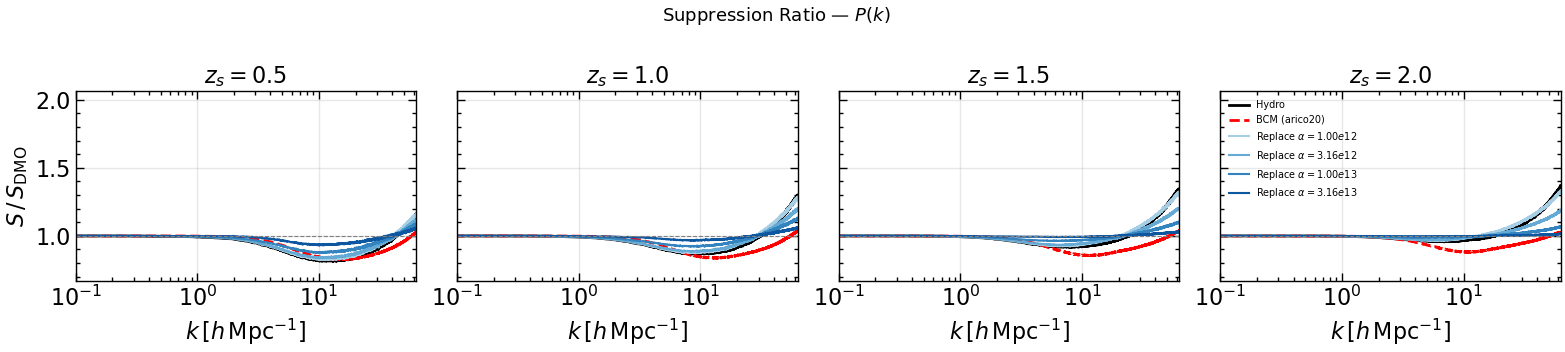

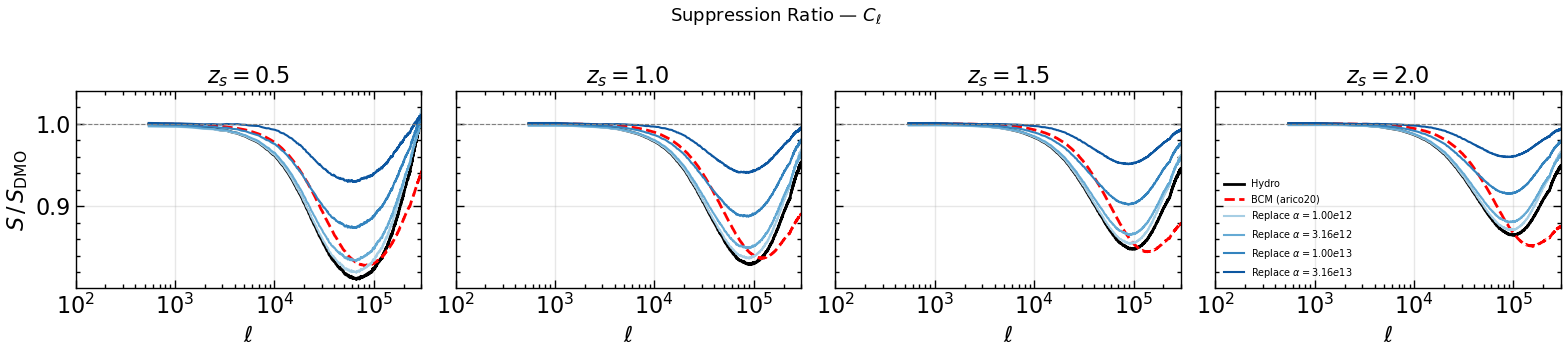

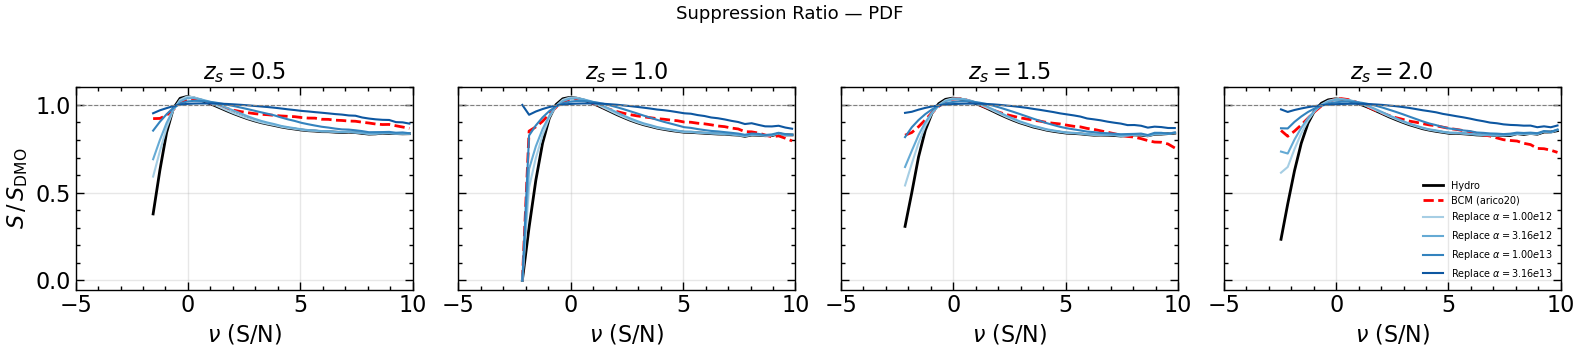

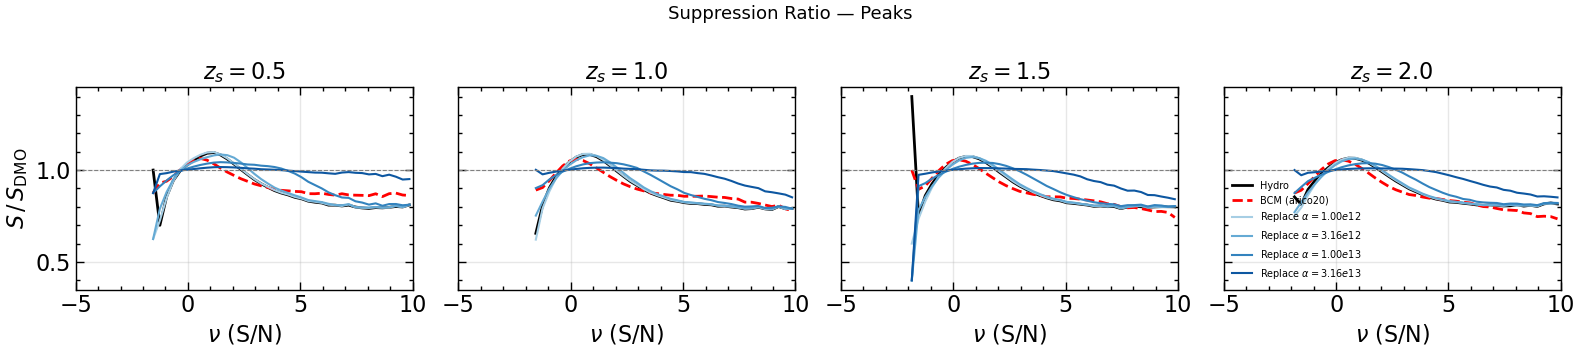

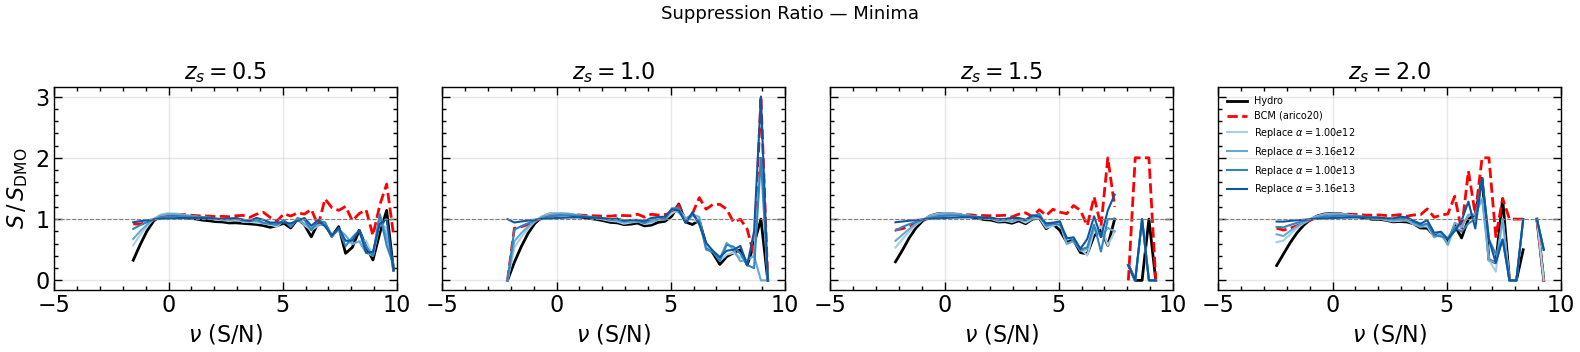

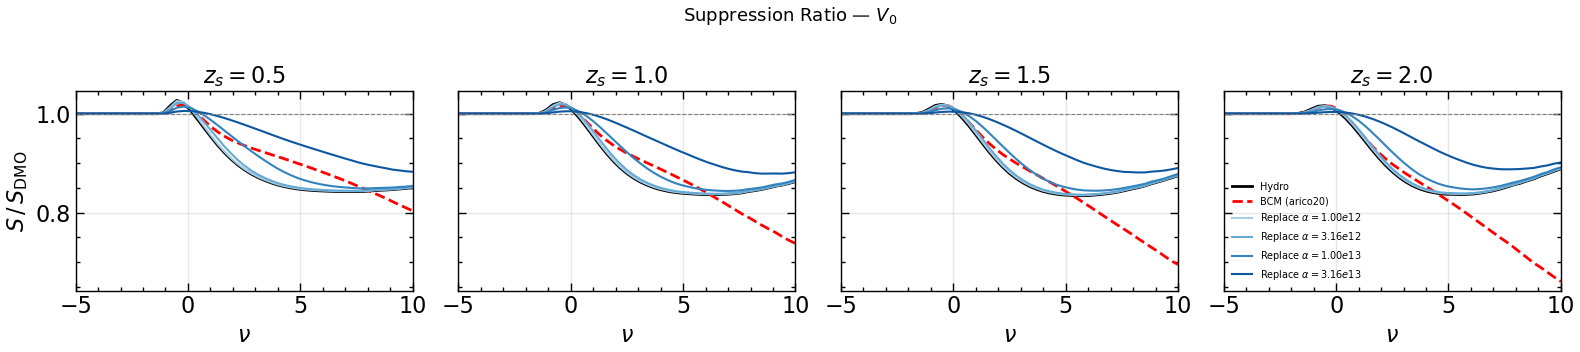

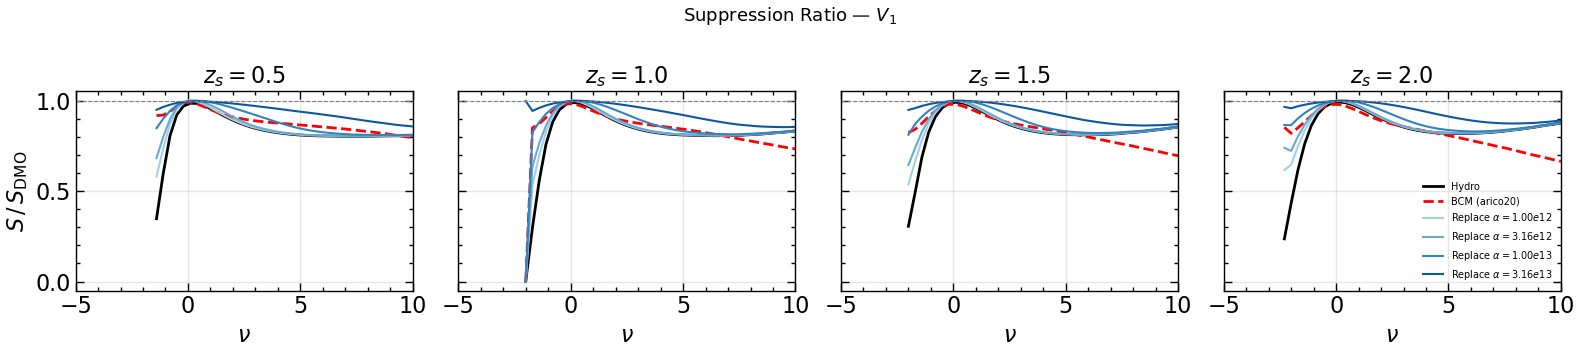

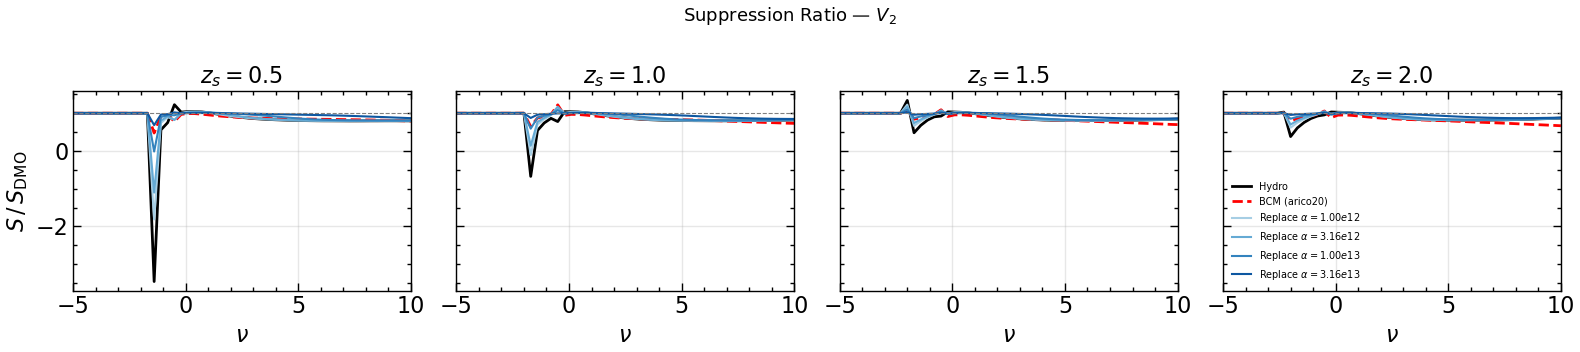

In [31]:
def plot_suppression_ratios(stat_name, z_indices=Z_INDICES, z_labels_list=z_labels):
    """
    Plot S/S_DMO for Hydro, BCM, and Replace overlay models.
    One panel per redshift.
    """
    xax = STAT_XAXIS[stat_name]
    bin_key = xax['bin_key']
    if stat_name in DIRECT_BIN_STATS:
        bins = base_stats['hydro'][bin_key]
    else:
        bin_edges = base_stats['hydro'][bin_key]
        bins = bin_edges[1:] - 0.5 * np.median(np.diff(bin_edges))

    n_z = len(z_indices)
    fig, axes = plt.subplots(1, n_z, figsize=(4 * n_z, 3.5), sharey=True)
    if n_z == 1:
        axes = [axes]

    replace_colors = plt.cm.Blues(np.linspace(0.35, 0.85, len(CUM_OVERLAY_MODELS)))

    for col, (zi, zl) in enumerate(zip(z_indices, z_labels_list)):
        ax = axes[col]
        dmo_mean = base_stats['dmo'][stat_name].mean(axis=0)[zi]

        # Hydro
        hydro_mean = base_stats['hydro'][stat_name].mean(axis=0)[zi]
        with np.errstate(divide='ignore', invalid='ignore'):
            ax.plot(bins, hydro_mean / dmo_mean, 'k-', lw=2, label='Hydro')

        # BCM
        for bname, bdata in bcm_stats.items():
            bcm_mean = bdata[stat_name].mean(axis=0)[zi]
            with np.errstate(divide='ignore', invalid='ignore'):
                ax.plot(bins, bcm_mean / dmo_mean, 'r--', lw=2, label=f'BCM ({bname})')

        # Replace overlays
        for j, (rname, rdata) in enumerate(replace_stats.items()):
            # ro = rname.split('Ro_')[1]
            ro = rname.split('Ml_')[1].split('_')[0]
            r_mean = rdata[stat_name].mean(axis=0)[zi]
            with np.errstate(divide='ignore', invalid='ignore'):
                ax.plot(bins, r_mean / dmo_mean, color=replace_colors[j], lw=1.5,
                        label=rf'Replace $\alpha={ro}$')

        ax.axhline(1, color='grey', ls='--', lw=0.8)
        ax.set_xscale(xax['xscale'])
        ax.set_xlim(xax['xlim'])
        ax.set_xlabel(xax['xlabel'])
        ax.set_title(zl)
        ax.grid(alpha=0.3)
        if col == 0:
            ax.set_ylabel(r'$S\,/\,S_{\rm DMO}$')
        if col == n_z - 1:
            ax.legend(fontsize=7, loc='best')

    fig.suptitle(rf'Suppression Ratio — {STAT_LABELS[stat_name]}', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
    return fig


# Plot suppression ratios for all statistics
for stat in STATISTICS:
    plot_suppression_ratios(stat)


## 2. Response Fraction $F$ (bin-by-bin) at $z_s = 1$

$F = (S_{\rm model} - S_{\rm DMO}) / (S_{\rm Hydro} - S_{\rm DMO})$

BCM (red) vs Replace overlay models (blue shades) for the 6 non-spectral statistics. $F=1$ means the model fully reproduces the hydrodynamical result.


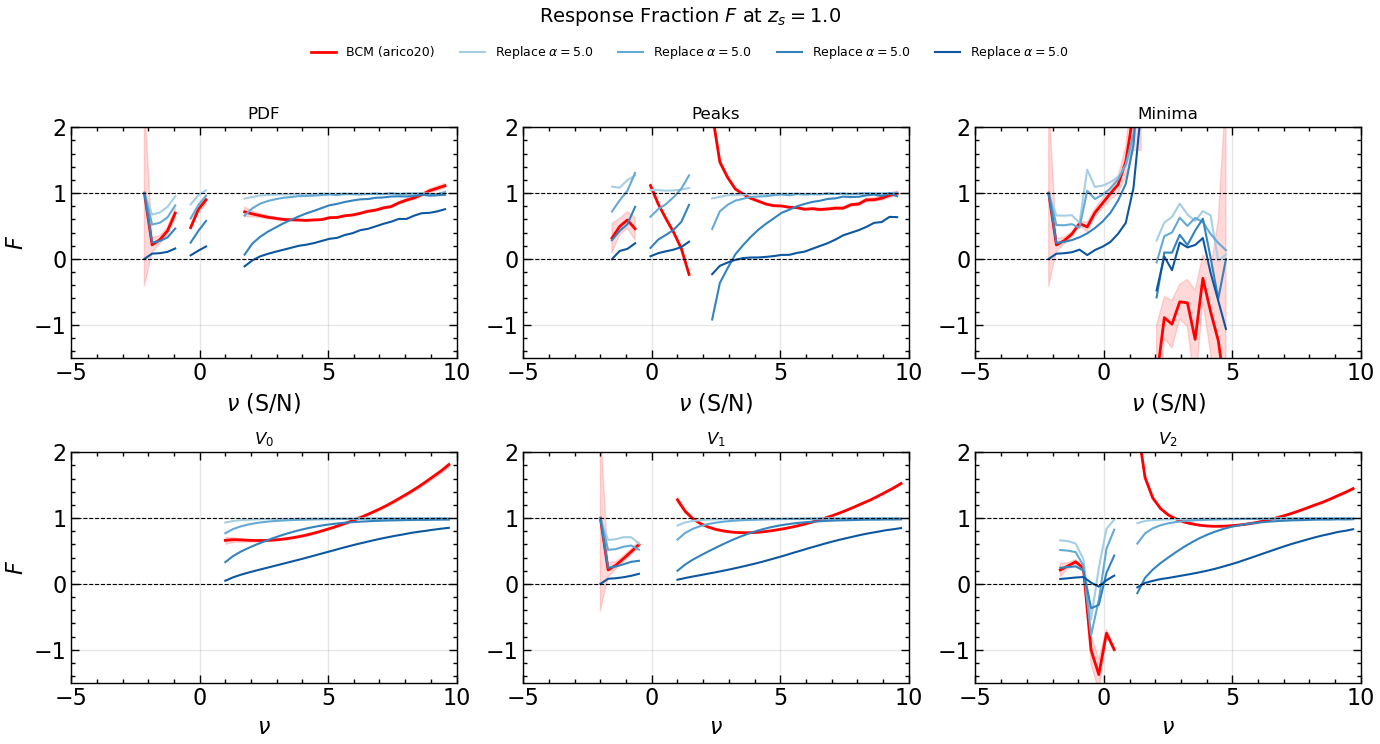

In [32]:

# ============================================================
# 6-panel F(bin) at z=1 for non-spectral statistics
# ============================================================

PANEL_STATS = ['pdf', 'peaks', 'minima', 'V0', 'V1', 'V2']
z_idx, z_val = 23, 1.0

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

replace_colors = plt.cm.Blues(np.linspace(0.35, 0.85, len(CUM_OVERLAY_MODELS)))

for idx, stat in enumerate(PANEL_STATS):
    ax = axes[idx]
    xax = STAT_XAXIS[stat]
    bins = bcm_bins[stat]

    # BCM
    for bname in bcm_F:
        F = bcm_F[bname][stat][z_idx]
        F_err = bcm_F_err[bname][stat][z_idx]
        ax.plot(bins, F, 'r-', lw=2, label=f'BCM ({bname})' if idx == 0 else None)
        ax.fill_between(bins, F - np.abs(F_err), F + np.abs(F_err),
                        color='red', alpha=0.15)

    # Replace overlays
    for j, rname in enumerate(CUM_OVERLAY_MODELS):
        if rname not in replace_F:
            continue
        ro = rname.split('Ro_')[1]
        F = replace_F[rname][stat][z_idx]
        ax.plot(bins, F, color=replace_colors[j], lw=1.5,
                label=rf'Replace $\alpha={ro}$' if idx == 0 else None)

    ax.axhline(0, color='k', ls='--', lw=0.8)
    ax.axhline(1, color='k', ls='--', lw=0.8)
    ax.set_ylim(-1.5, 2.0)
    ax.set_xscale(xax['xscale'])
    ax.set_xlim(xax['xlim'])
    ax.set_xlabel(xax['xlabel'])
    ax.set_title(STAT_LABELS[stat], fontsize=12)
    ax.grid(alpha=0.3)
    if idx % 3 == 0:
        ax.set_ylabel(r'$F$')

# Shared legend from first panel
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(handles),
           fontsize=9, bbox_to_anchor=(0.5, 1.03))

fig.suptitle(rf'Response Fraction $F$ at $z_s = {z_val}$', fontsize=14, y=1.07)
plt.tight_layout()
plt.show()


## 3. SNR-Weighted $\langle F \rangle$ vs Redshift

Scalar summary per statistic and redshift — exactly matching the weighting in `response_analysis_h5.ipynb`:

$$\langle F \rangle_{\rm SNR} = \frac{\sum_i w_i\, F_i}{\sum_i w_i}, \qquad w_i = \left|\frac{H_i - D_i}{D_i}\right| \cdot \frac{1}{\sigma_{F,i}^2}$$

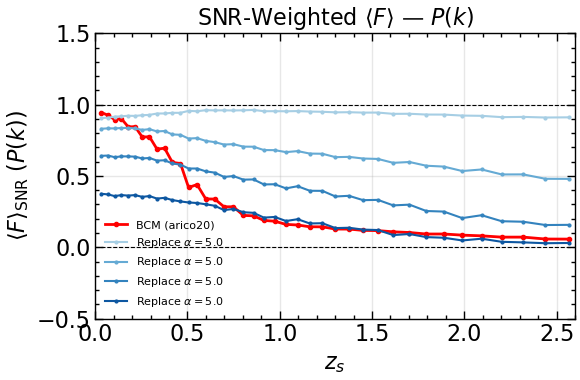

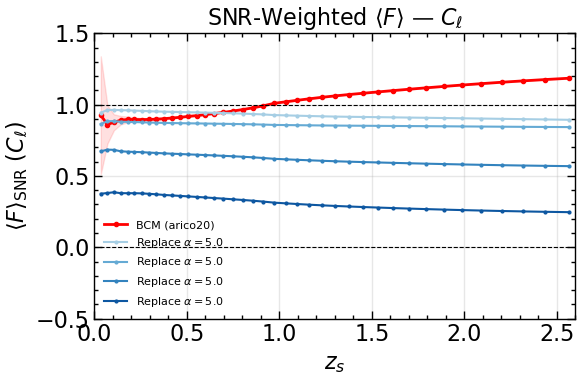

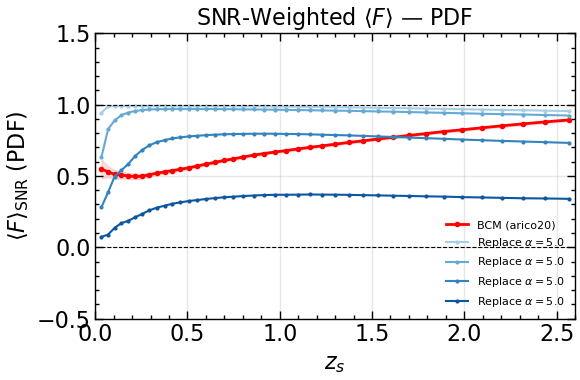

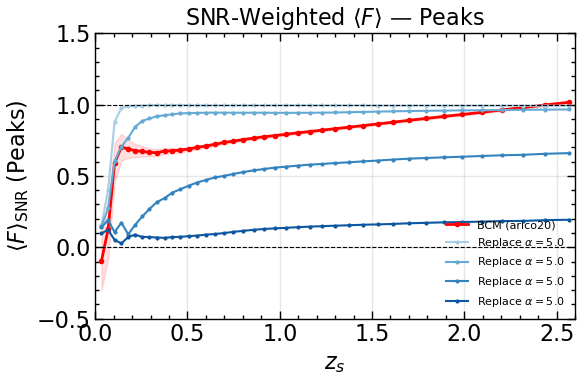

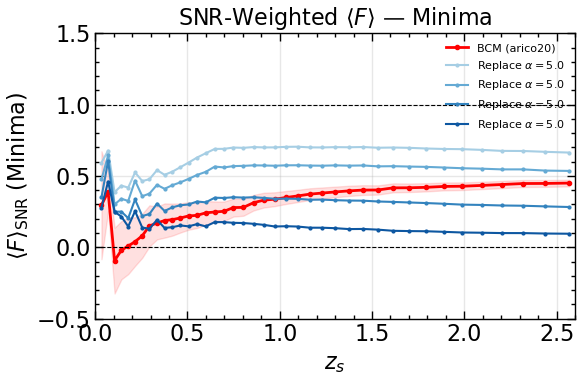

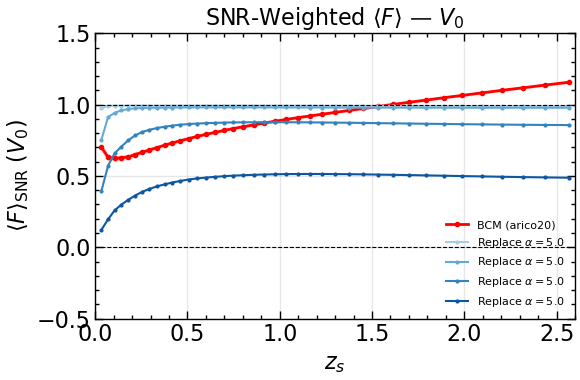

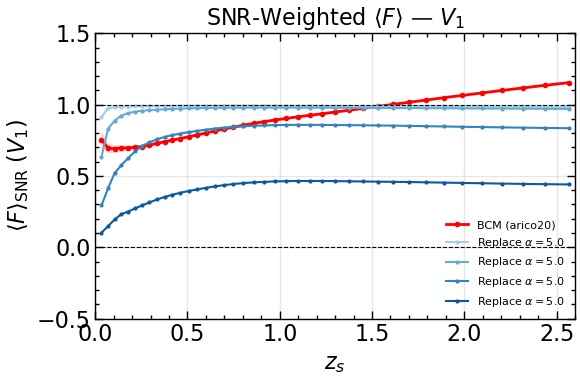

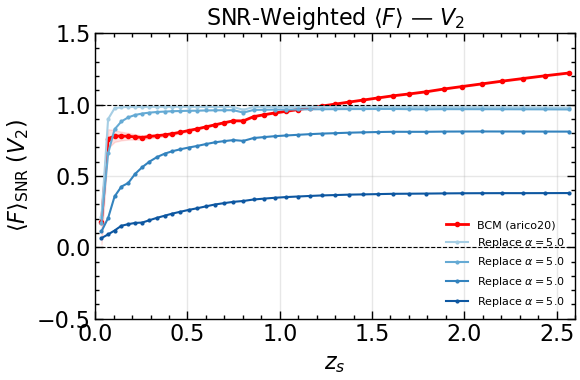

In [33]:
# ============================================================
# SNR-weighted <F> vs redshift for BCM and Replace models
# ============================================================

def plot_snr_weighted_F_vs_z(stat_name, weighting='snr_weighted_F'):
    """
    Plot the scalar SNR-weighted <F> as a function of source redshift
    for BCM and Replace overlay models.
    """
    fig, ax = plt.subplots(figsize=(6, 4))
    replace_colors = plt.cm.Blues(np.linspace(0.35, 0.85, len(CUM_OVERLAY_MODELS)))

    # BCM
    for bname in bcm_scores:
        F_vs_z = bcm_scores[bname][stat_name][weighting]
        F_err_vs_z = bcm_scores[bname][stat_name].get(f'{weighting}_err',
                      np.full_like(F_vs_z, np.nan))
        ax.plot(REDSHIFTS_ALL, F_vs_z, 'r-o', lw=2, ms=3,
                label=f'BCM ({bname})')
        valid = np.isfinite(F_err_vs_z)
        ax.fill_between(np.array(REDSHIFTS_ALL)[valid],
                         (F_vs_z - np.abs(F_err_vs_z))[valid],
                         (F_vs_z + np.abs(F_err_vs_z))[valid],
                         color='red', alpha=0.12)

    # Replace overlays
    for j, rname in enumerate(CUM_OVERLAY_MODELS):
        if rname not in replace_scores:
            continue
        ro = rname.split('Ro_')[1]
        F_vs_z = replace_scores[rname][stat_name][weighting]
        ax.plot(REDSHIFTS_ALL, F_vs_z, '-o', color=replace_colors[j],
                lw=1.5, ms=2, label=rf'Replace $\alpha={ro}$')

    ax.axhline(0, color='k', ls='--', lw=0.8)
    ax.axhline(1, color='k', ls='--', lw=0.8)
    ax.set_xlim(0, 2.6)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel(r'$z_s$')
    ax.set_ylabel(rf'$\langle F \rangle_{{\rm SNR}}$ ({STAT_LABELS[stat_name]})')
    ax.set_title(rf'SNR-Weighted $\langle F \rangle$ — {STAT_LABELS[stat_name]}')
    ax.legend(fontsize=8, loc='best')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return fig


for stat in STATISTICS:
    plot_snr_weighted_F_vs_z(stat)

## 4. Summary Heatmap: SNR-Weighted $\langle F \rangle$ at Fixed Redshift

One value per statistic per model. Matches the heatmap style in `response_analysis_h5.ipynb`.

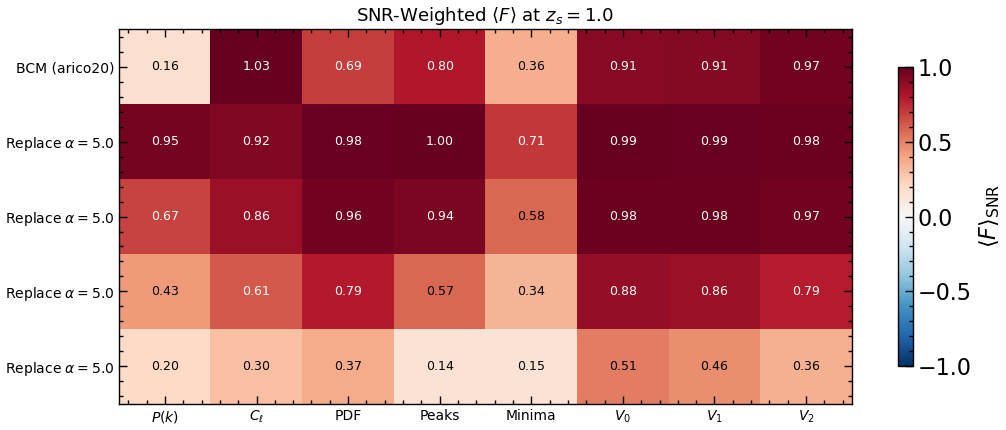

In [34]:
# ============================================================
# Summary heatmap: <F>_SNR for all models × all statistics
# at a fixed redshift
# ============================================================

def plot_bcm_summary_heatmap(z_idx=23, z_val=1.0, weighting='snr_weighted_F'):
    """
    Heatmap: rows = models (BCM + Replace overlays), cols = statistics.
    Cell colour = SNR-weighted <F>.
    """
    model_labels = []
    model_keys = []  # (source_dict, model_name)

    for bname in bcm_scores:
        model_labels.append(f'BCM ({bname})')
        model_keys.append(('bcm', bname))
    for rname in CUM_OVERLAY_MODELS:
        if rname in replace_scores:
            ro = rname.split('Ro_')[1]
            model_labels.append(rf'Replace $\alpha={ro}$')
            model_keys.append(('replace', rname))

    n_models = len(model_labels)
    n_stats = len(STATISTICS)

    matrix = np.full((n_models, n_stats), np.nan)
    for i, (src, mname) in enumerate(model_keys):
        scores_dict = bcm_scores if src == 'bcm' else replace_scores
        for j, stat in enumerate(STATISTICS):
            val = scores_dict[mname][stat][weighting][z_idx]
            matrix[i, j] = val

    fig, ax = plt.subplots(figsize=(n_stats * 1.2 + 1, n_models * 0.7 + 1))
    im = ax.imshow(matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

    # Annotate
    for i in range(n_models):
        for j in range(n_stats):
            val = matrix[i, j]
            if np.isfinite(val):
                color = 'white' if abs(val) > 0.6 else 'black'
                ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                        fontsize=9, color=color)

    ax.set_xticks(range(n_stats))
    ax.set_xticklabels([STAT_LABELS[s] for s in STATISTICS], fontsize=10)
    ax.set_yticks(range(n_models))
    ax.set_yticklabels(model_labels, fontsize=10)
    plt.colorbar(im, ax=ax, label=r'$\langle F \rangle_{\rm SNR}$', shrink=0.8)
    ax.set_title(rf'SNR-Weighted $\langle F \rangle$ at $z_s = {z_val}$', fontsize=13)
    plt.tight_layout()
    plt.show()
    return fig, matrix


fig, matrix = plot_bcm_summary_heatmap(z_idx=23, z_val=1.0)

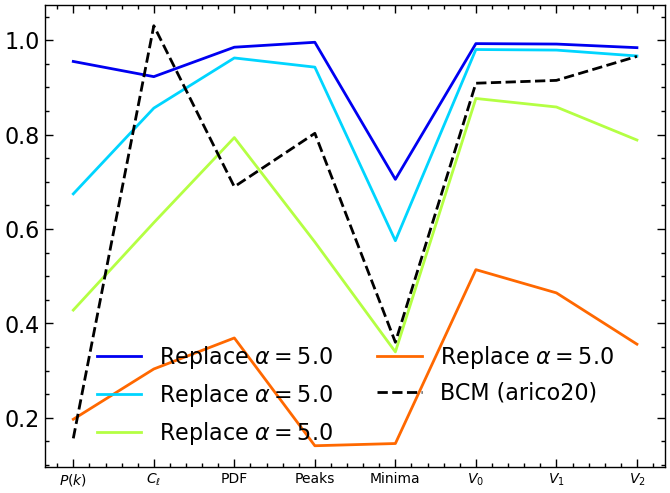

In [35]:
model_labels = []
model_keys = []  # (source_dict, model_name)
for bname in bcm_scores:
    model_labels.append(f'BCM ({bname})')
    model_keys.append(('bcm', bname))
for rname in CUM_OVERLAY_MODELS:
    if rname in replace_scores:
        ro = rname.split('Ro_')[1]
        model_labels.append(rf'Replace $\alpha={ro}$')
        model_keys.append(('replace', rname))
cs = plt.cm.jet(np.linspace(0.1, 0.8, 4))
fig, axs = plt.subplots(1, 1)
for i in range(4):
    axs.plot(matrix[1+i], c=cs[i], label=model_labels[1+i], lw=2)
axs.plot(matrix[0], label=model_labels[0], lw=2, c='black', ls='--')
axs.set_xticks(np.arange(8))
axs.set_xticklabels([STAT_LABELS[s] for s in STATISTICS], fontsize=10)
axs.legend(ncols=2)

## 5. Combined $\langle F \rangle_{\rm SNR}$ vs Redshift — All Statistics

One panel per statistic, all on the same figure for compact comparison.

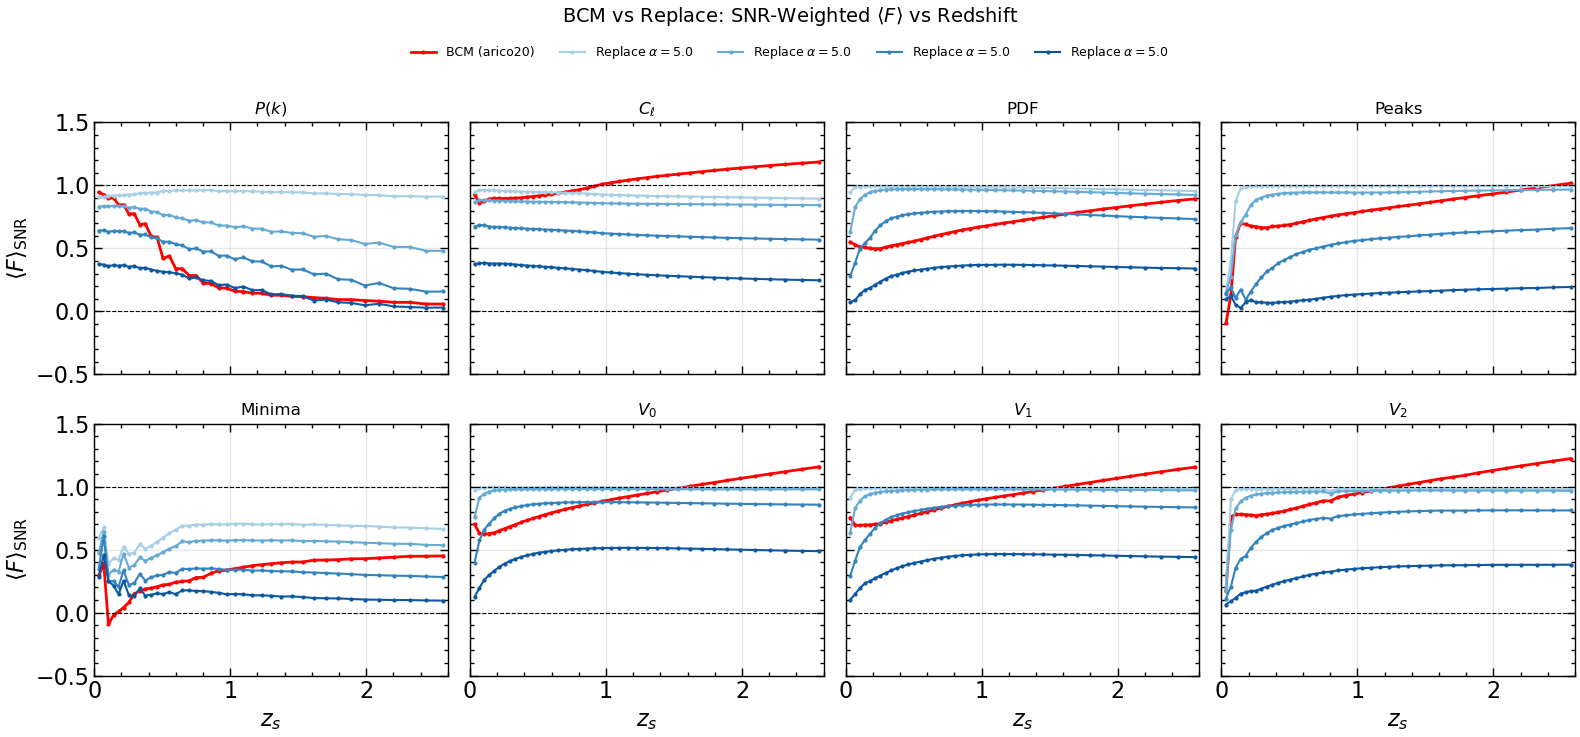

In [36]:
# ============================================================
# Combined multi-panel: <F>_SNR vs z for all 8 statistics
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True, sharey=True)
axes = axes.flatten()

replace_colors = plt.cm.Blues(np.linspace(0.35, 0.85, len(CUM_OVERLAY_MODELS)))
weighting = 'snr_weighted_F'

for idx, stat in enumerate(STATISTICS):
    ax = axes[idx]

    # BCM
    for bname in bcm_scores:
        F_vs_z = bcm_scores[bname][stat][weighting]
        ax.plot(REDSHIFTS_ALL, F_vs_z, 'r-o', lw=2, ms=2,
                label=f'BCM ({bname})' if idx == 0 else None)

    # Replace overlays
    for j, rname in enumerate(CUM_OVERLAY_MODELS):
        if rname not in replace_scores:
            continue
        ro = rname.split('Ro_')[1]
        F_vs_z = replace_scores[rname][stat][weighting]
        ax.plot(REDSHIFTS_ALL, F_vs_z, '-o', color=replace_colors[j],
                lw=1.5, ms=2,
                label=rf'Replace $\alpha={ro}$' if idx == 0 else None)

    ax.axhline(0, color='k', ls='--', lw=0.8)
    ax.axhline(1, color='k', ls='--', lw=0.8)
    ax.set_xlim(0, 2.6)
    ax.set_ylim(-0.5, 1.5)
    ax.set_title(STAT_LABELS[stat], fontsize=12)
    ax.grid(alpha=0.3)
    if idx >= 4:
        ax.set_xlabel(r'$z_s$')
    if idx % 4 == 0:
        ax.set_ylabel(r'$\langle F \rangle_{\rm SNR}$')

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(handles),
           fontsize=9, bbox_to_anchor=(0.5, 1.02))

fig.suptitle(r'BCM vs Replace: SNR-Weighted $\langle F \rangle$ vs Redshift',
             fontsize=14, y=1.06)
plt.tight_layout()
plt.show()

## 6. Numerical Summary Table

Print $\langle F \rangle_{\rm SNR}$ for all models and statistics at the four fiducial redshifts.

In [37]:
# ============================================================
# Numerical summary: <F>_SNR at fiducial redshifts
# ============================================================

weighting = 'snr_weighted_F'

for zi, zl in zip(Z_INDICES, z_labels):
    print(f'\n{"=" * 80}')
    print(f'  {zl}   (z_idx = {zi})')
    print(f'{"=" * 80}')
    header = f'{"Model":<45}'
    for stat in STATISTICS:
        header += f' {STAT_LABELS[stat]:>7}'
    print(header)
    print('-' * (45 + 8 * len(STATISTICS)))

    # BCM
    for bname in bcm_scores:
        row = f'{"BCM (" + bname + ")":<45}'
        for stat in STATISTICS:
            val = bcm_scores[bname][stat][weighting][zi]
            row += f' {val:>7.3f}'
        print(row)

    # Replace overlays
    for rname in CUM_OVERLAY_MODELS:
        if rname not in replace_scores:
            continue
        ro = rname.split('Ro_')[1]
        label = f'Replace alpha={ro}'
        row = f'{label:<45}'
        for stat in STATISTICS:
            val = replace_scores[rname][stat][weighting][zi]
            row += f' {val:>7.3f}'
        print(row)

print('\nDone.')


  $z_s = 0.5$   (z_idx = 13)
Model                                          $P(k)$ $C_\ell$     PDF   Peaks  Minima   $V_0$   $V_1$   $V_2$
-------------------------------------------------------------------------------------------------------------
BCM (arico20)                                   0.440   0.923   0.570   0.700   0.224   0.777   0.787   0.830
Replace alpha=5.0                               0.954   0.946   0.991   0.995   0.629   0.993   0.992   0.984
Replace alpha=5.0                               0.765   0.868   0.970   0.942   0.507   0.981   0.976   0.958
Replace alpha=5.0                               0.552   0.649   0.782   0.454   0.321   0.867   0.816   0.710
Replace alpha=5.0                               0.310   0.353   0.331   0.082   0.162   0.482   0.406   0.273

  $z_s = 1.0$   (z_idx = 23)
Model                                          $P(k)$ $C_\ell$     PDF   Peaks  Minima   $V_0$   $V_1$   $V_2$
----------------------------------------------------------

In [12]:

## 7. Contextual Analysis: BCM Performance in the Replace Response Framework

The paper (§6, Fig. 8) establishes that each statistic has a distinct **baryonic fingerprint** in halo mass–radius space. Key findings from the Replace analysis:

- Even the most aggressive Replace ($M>10^{12}\,h^{-1}{\rm M}_\odot$, $\alpha=5R_{200}$) captures only ~90% of baryonic suppression in $P(k)$/$C_\ell$, and less for minima.
- Peak counts are sharply localized to cores ($r < R_{200}$) of $M \gtrsim 10^{12.5}\,h^{-1}{\rm M}_\odot$ halos.
- BCMs calibrated to $P(k)$ under-predict core masses by ~20% for $M < 10^{13}\,h^{-1}{\rm M}_\odot$ (Fig. 11), explaining discrepancies with peak statistics (Lee+2022).

We now ask: **where does the Arico+2020 BCM sit relative to Replace models across all 8 statistics?** This directly connects to Fig. 10 of the paper ($F^{\rm BCM}_P(k)$ tracking between Replace models).


SyntaxError: invalid character '§' (U+00A7) (4041048114.py, line 3)

In [38]:

# ============================================================
# 7a. BCM "equivalent Replace model" — which Replace model does
#     the BCM most closely match for each statistic?
#
# For each statistic at z=1, find the Replace overlay model whose
# SNR-weighted <F> is closest to the BCM's. This tells us the
# "effective mass threshold" the BCM operates at per statistic.
# ============================================================

z_idx_ctx = 23  # z ~ 1
weighting = 'snr_weighted_F'

print(f'BCM "equivalent Replace model" at z_s ~ 1.0')
print(f'{"Statistic":<12} {"BCM <F>_SNR":>12} {"Closest Replace":>30} {"Replace <F>":>12} {"Δ":>8}')
print('-' * 78)

bcm_name = list(bcm_scores.keys())[0]
equiv_replace = {}

for stat in STATISTICS:
    bcm_val = bcm_scores[bcm_name][stat][weighting][z_idx_ctx]
    
    best_match = None
    best_dist = np.inf
    best_val = np.nan
    for rname in CUM_OVERLAY_MODELS:
        if rname not in replace_scores:
            continue
        rval = replace_scores[rname][stat][weighting][z_idx_ctx]
        dist = abs(rval - bcm_val)
        if dist < best_dist:
            best_dist = dist
            best_match = rname
            best_val = rval
    
    ro = best_match.split('Ro_')[1] if best_match else '?'
    equiv_replace[stat] = {'name': best_match, 'ro': ro, 'val': best_val}
    print(f'{STAT_LABELS[stat]:<12} {bcm_val:>12.3f} {f"Replace α={ro}":>30} {best_val:>12.3f} {bcm_val - best_val:>+8.3f}')


BCM "equivalent Replace model" at z_s ~ 1.0
Statistic     BCM <F>_SNR                Closest Replace  Replace <F>        Δ
------------------------------------------------------------------------------
$P(k)$              0.156                  Replace α=5.0        0.197   -0.040
$C_\ell$            1.030                  Replace α=5.0        0.923   +0.108
PDF                 0.689                  Replace α=5.0        0.794   -0.104
Peaks               0.803                  Replace α=5.0        0.943   -0.140
Minima              0.360                  Replace α=5.0        0.339   +0.020
$V_0$               0.909                  Replace α=5.0        0.876   +0.032
$V_1$               0.915                  Replace α=5.0        0.858   +0.056
$V_2$               0.966                  Replace α=5.0        0.966   -0.001


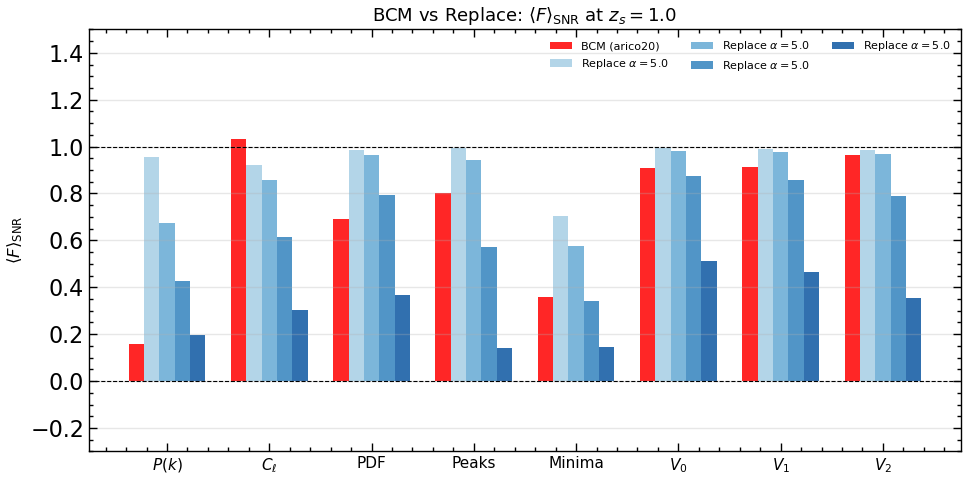

In [39]:

# ============================================================
# 7b. Radar / bar chart: BCM <F>_SNR vs Replace models per stat
#     Shows whether the BCM is self-consistent across statistics
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(STATISTICS))
width = 0.15

# BCM bar
bcm_vals = [bcm_scores[bcm_name][stat][weighting][z_idx_ctx] for stat in STATISTICS]
ax.bar(x - 2*width, bcm_vals, width, color='red', alpha=0.85, label=f'BCM ({bcm_name})')

# Replace overlay bars
replace_colors_bar = plt.cm.Blues(np.linspace(0.35, 0.85, len(CUM_OVERLAY_MODELS)))
for j, rname in enumerate(CUM_OVERLAY_MODELS):
    if rname not in replace_scores:
        continue
    ro = rname.split('Ro_')[1]
    vals = [replace_scores[rname][stat][weighting][z_idx_ctx] for stat in STATISTICS]
    ax.bar(x + (j-1)*width, vals, width, color=replace_colors_bar[j],
           alpha=0.85, label=rf'Replace $\alpha={ro}$')

ax.axhline(1, color='k', ls='--', lw=0.8)
ax.axhline(0, color='k', ls='--', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([STAT_LABELS[s] for s in STATISTICS], fontsize=11)
ax.set_ylabel(r'$\langle F \rangle_{\rm SNR}$', fontsize=12)
ax.set_title(r'BCM vs Replace: $\langle F \rangle_{\rm SNR}$ at $z_s = 1.0$', fontsize=13)
ax.set_ylim(-0.3, 1.5)
ax.legend(fontsize=8, ncol=3, loc='upper right')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()



### 7c. BCM Self-Consistency Test

The paper argues (§6) that a BCM calibrated to $P(k)$ can trade baryonic effects between $(M, r)$ regions that are degenerate for $P(k)$ but distinguishable by other statistics. If the BCM is truly self-consistent, its $\langle F \rangle_{\rm SNR}$ should *rank similarly* across statistics as the Replace models do. Any statistic where the BCM deviates from the Replace trend reveals where the spatial placement of baryons is incorrect.

We quantify this by computing the **BCM$-$Replace residual** for each statistic: $\Delta F_S = \langle F_S^{\rm BCM} \rangle - \langle F_S^{\rm Replace}(\alpha) \rangle$ at fixed $\alpha$. If $\Delta F_S$ varies across statistics, the BCM is redistributing baryonic effects differently than true halo-level Replacement would.


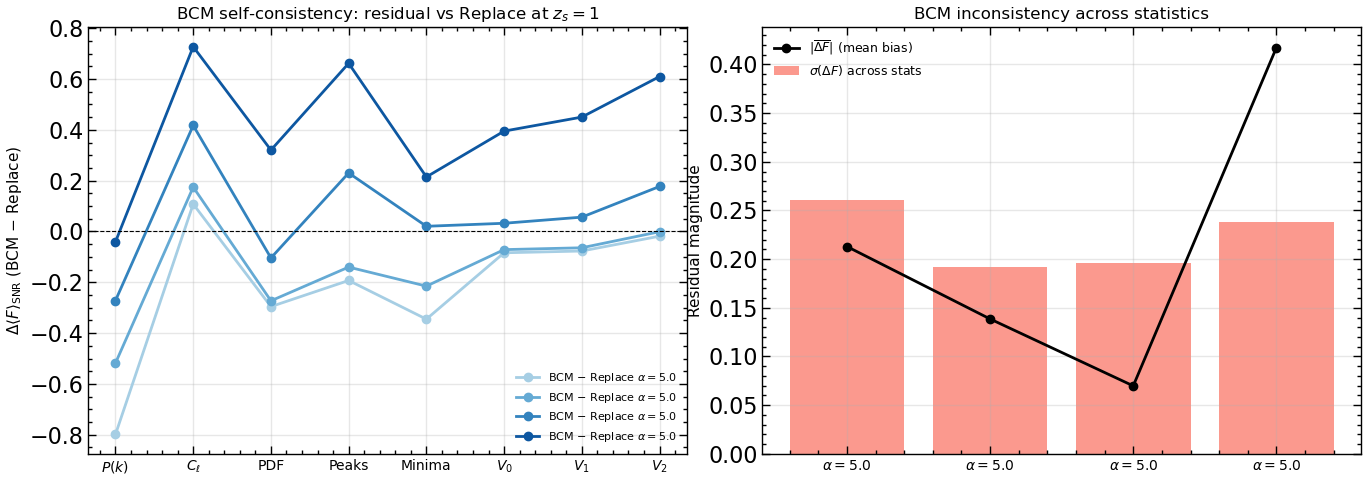

In [40]:

# ============================================================
# 7c. BCM − Replace residual profiles across statistics
#     If BCM were perfectly self-consistent, the residual ΔF
#     would be ~constant across statistics for a given α.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: ΔF = BCM − Replace(α) for each statistic
ax = axes[0]
replace_colors_line = plt.cm.Blues(np.linspace(0.35, 0.85, len(CUM_OVERLAY_MODELS)))
stat_x = np.arange(len(STATISTICS))

for j, rname in enumerate(CUM_OVERLAY_MODELS):
    if rname not in replace_scores:
        continue
    ro = rname.split('Ro_')[1]
    delta_F = []
    for stat in STATISTICS:
        bcm_val = bcm_scores[bcm_name][stat][weighting][z_idx_ctx]
        rep_val = replace_scores[rname][stat][weighting][z_idx_ctx]
        delta_F.append(bcm_val - rep_val)
    ax.plot(stat_x, delta_F, '-o', color=replace_colors_line[j], lw=2, ms=6,
            label=rf'BCM $-$ Replace $\alpha={ro}$')

ax.axhline(0, color='k', ls='--', lw=0.8)
ax.set_xticks(stat_x)
ax.set_xticklabels([STAT_LABELS[s] for s in STATISTICS], fontsize=10)
ax.set_ylabel(r'$\Delta\langle F \rangle_{\rm SNR}$ (BCM $-$ Replace)', fontsize=11)
ax.set_title(r'BCM self-consistency: residual vs Replace at $z_s=1$', fontsize=12)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Right panel: Scatter of ΔF across statistics (std) for each α
ax2 = axes[1]
alphas_float = []
delta_F_std = []
delta_F_mean = []
for j, rname in enumerate(CUM_OVERLAY_MODELS):
    if rname not in replace_scores:
        continue
    ro = rname.split('Ro_')[1]
    alphas_float.append(float(ro))
    resid = []
    for stat in STATISTICS:
        bcm_val = bcm_scores[bcm_name][stat][weighting][z_idx_ctx]
        rep_val = replace_scores[rname][stat][weighting][z_idx_ctx]
        resid.append(bcm_val - rep_val)
    delta_F_std.append(np.std(resid))
    delta_F_mean.append(np.mean(resid))

ax2.bar(range(len(alphas_float)), delta_F_std, color='salmon', alpha=0.8, label=r'$\sigma(\Delta F)$ across stats')
ax2.plot(range(len(alphas_float)), np.abs(delta_F_mean), 'ko-', ms=6, label=r'$|\overline{\Delta F}|$ (mean bias)')
ax2.set_xticks(range(len(alphas_float)))
ax2.set_xticklabels([rf'$\alpha={a}$' for a in alphas_float], fontsize=10)
ax2.set_ylabel('Residual magnitude', fontsize=11)
ax2.set_title('BCM inconsistency across statistics', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()



### 7d. Statistic-Dependent BCM Performance: Connecting to the Baryonic Fingerprint

The paper (Fig. 8) shows that **non-Gaussian statistics are more sensitive to halo cores** than $P(k)$ or $C_\ell$. Specifically:
- **Peaks**: dominated by cores of $10^{12.5}-10^{13.5}\,M_\odot$ halos
- **PDF**: similar to peaks but broader in mass
- **Minima**: weak response overall; sensitive to underdense regions
- **$V_0, V_1, V_2$**: intermediate; $V_1$ most sensitive to massive clusters

Since BCMs under-predict core masses for $M < 10^{13}\,h^{-1}{\rm M}_\odot$ by ~20% (Fig. 11-12), we **predict** the BCM should perform worse on statistics dominated by these intermediate-mass cores (peaks, PDF) and better on statistics sensitive to the mass ranges where BCMs are more accurate (clusters).

Below we plot the BCM $\langle F \rangle_{\rm SNR}$ as a function of redshift for all 6 non-spectral statistics in a single panel, to see if the ordering is consistent with these predictions.


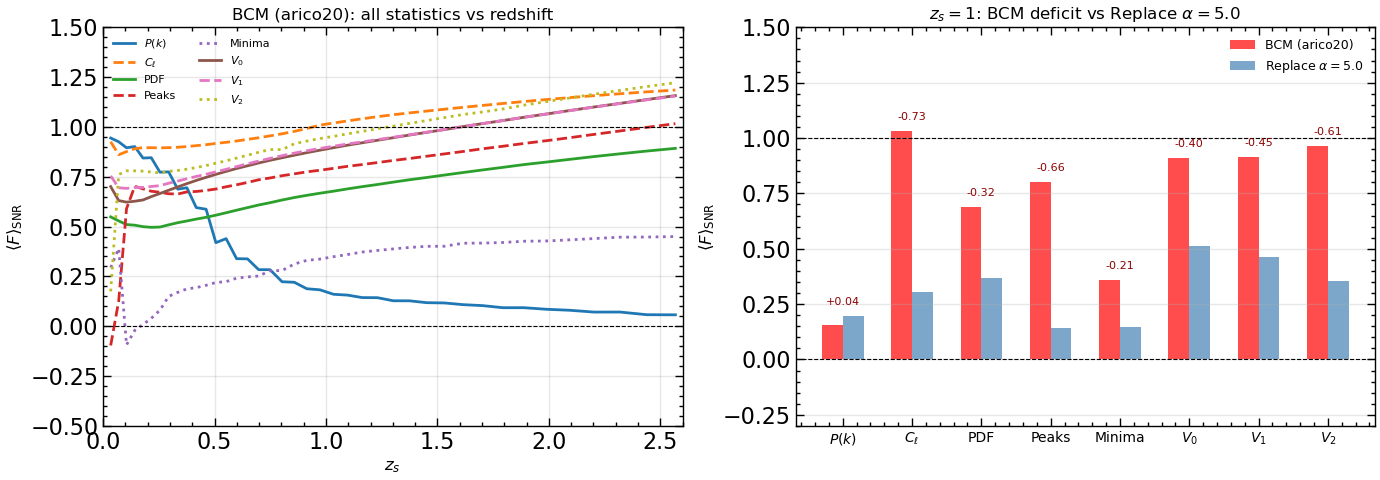

In [41]:

# ============================================================
# 7d. BCM <F>_SNR vs redshift for all statistics on one panel
#     Color-coded by statistic type
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Statistic colors
stat_colors = plt.cm.tab10(np.linspace(0, 0.8, len(STATISTICS)))
stat_ls = {
    'Pk': '-', 'Cl': '--',
    'pdf': '-', 'peaks': '--', 'minima': ':',
    'V0': '-', 'V1': '--', 'V2': ':'
}

# Left: BCM <F> vs z for all statistics
ax = axes[0]
for i, stat in enumerate(STATISTICS):
    F_vs_z = bcm_scores[bcm_name][stat][weighting]
    ax.plot(REDSHIFTS_ALL, F_vs_z, stat_ls.get(stat, '-'),
            color=stat_colors[i], lw=2, label=STAT_LABELS[stat])

ax.axhline(1, color='k', ls='--', lw=0.8)
ax.axhline(0, color='k', ls='--', lw=0.8)
ax.set_xlim(0, 2.6)
ax.set_ylim(-0.5, 1.5)
ax.set_xlabel(r'$z_s$', fontsize=12)
ax.set_ylabel(r'$\langle F \rangle_{\rm SNR}$', fontsize=12)
ax.set_title(f'BCM ({bcm_name}): all statistics vs redshift', fontsize=12)
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)

# Right: At z=1, show BCM vs best Replace (α=5) as deficit
ax2 = axes[1]
best_replace = CUM_OVERLAY_MODELS[-1]  # α=5 is the most complete
if best_replace in replace_scores:
    ro = best_replace.split('Ro_')[1]
    stat_x = np.arange(len(STATISTICS))
    
    bcm_vals = np.array([bcm_scores[bcm_name][stat][weighting][z_idx_ctx] for stat in STATISTICS])
    rep_vals = np.array([replace_scores[best_replace][stat][weighting][z_idx_ctx] for stat in STATISTICS])
    
    bars = ax2.bar(stat_x - 0.15, bcm_vals, 0.3, color='red', alpha=0.7, label=f'BCM ({bcm_name})')
    bars2 = ax2.bar(stat_x + 0.15, rep_vals, 0.3, color='steelblue', alpha=0.7, label=rf'Replace $\alpha={ro}$')
    
    # Annotate the gap
    for i_s in range(len(STATISTICS)):
        gap = rep_vals[i_s] - bcm_vals[i_s]
        if abs(gap) > 0.02:
            y_pos = max(bcm_vals[i_s], rep_vals[i_s]) + 0.05
            ax2.annotate(f'{gap:+.2f}', xy=(stat_x[i_s], y_pos),
                        ha='center', fontsize=8, color='darkred')
    
    ax2.axhline(1, color='k', ls='--', lw=0.8)
    ax2.axhline(0, color='k', ls='--', lw=0.8)
    ax2.set_xticks(stat_x)
    ax2.set_xticklabels([STAT_LABELS[s] for s in STATISTICS], fontsize=10)
    ax2.set_ylabel(r'$\langle F \rangle_{\rm SNR}$', fontsize=12)
    ax2.set_title(rf'$z_s=1$: BCM deficit vs Replace $\alpha={ro}$', fontsize=12)
    ax2.legend(fontsize=9)
    ax2.grid(alpha=0.3, axis='y')
    ax2.set_ylim(-0.3, 1.5)

plt.tight_layout()
plt.show()



### 7e. Key Diagnostic: Bin-by-bin $F$ Comparison for Peaks and PDF

The paper highlights peaks and the PDF as the statistics most sensitive to intermediate-mass halo cores — exactly where BCMs fail at the profile level (Figs. 11-12). Below we overlay the BCM's bin-by-bin $F(\nu)$ against the Replace models at $z=1$ for peaks and PDF side-by-side. If the BCM under-predicts $F$ at intermediate $\nu$ (where $10^{12.5}-10^{13}\,M_\odot$ halos dominate the peak response), this directly confirms the core under-concentration mechanism identified in the paper.


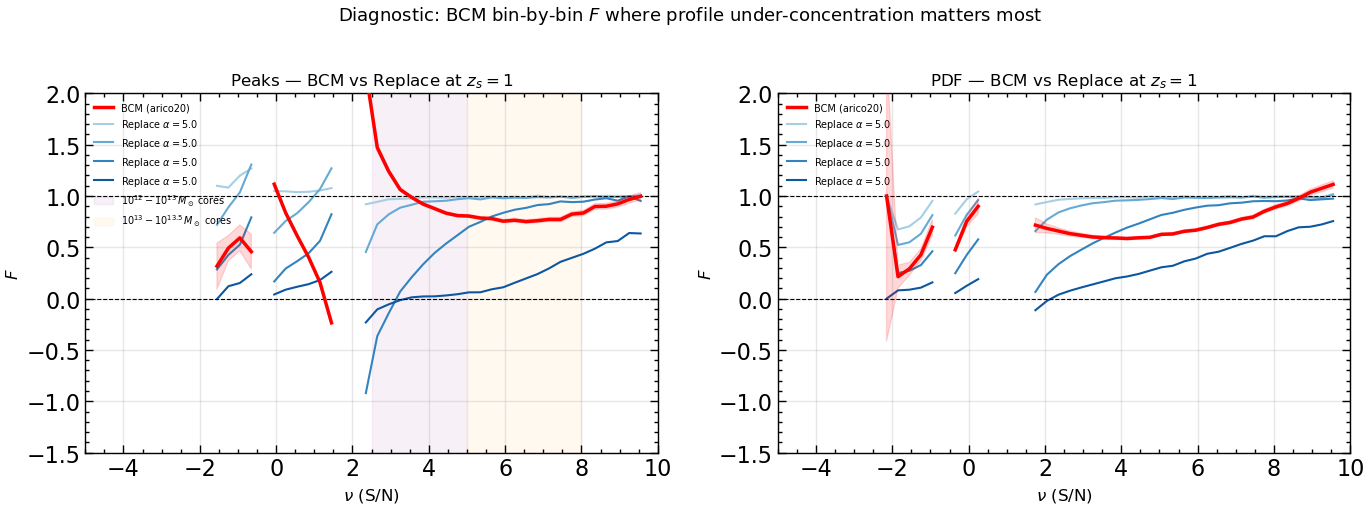

In [42]:

# ============================================================
# 7e. Detailed F(ν) for peaks and PDF at z=1: BCM vs Replace
#     with annotations of the mass ranges dominating each ν region
# ============================================================

DIAGNOSTIC_STATS = ['peaks', 'pdf']
z_idx_diag = 23

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
replace_colors_diag = plt.cm.Blues(np.linspace(0.35, 0.85, len(CUM_OVERLAY_MODELS)))

for col, stat in enumerate(DIAGNOSTIC_STATS):
    ax = axes[col]
    xax = STAT_XAXIS[stat]
    bins = bcm_bins[stat]
    
    # BCM
    F = bcm_F[bcm_name][stat][z_idx_diag]
    F_err = bcm_F_err[bcm_name][stat][z_idx_diag]
    ax.plot(bins, F, 'r-', lw=2.5, label=f'BCM ({bcm_name})', zorder=10)
    ax.fill_between(bins, F - np.abs(F_err), F + np.abs(F_err),
                    color='red', alpha=0.15, zorder=9)
    
    # Replace overlays
    for j, rname in enumerate(CUM_OVERLAY_MODELS):
        if rname not in replace_F:
            continue
        ro = rname.split('Ro_')[1]
        F_rep = replace_F[rname][stat][z_idx_diag]
        ax.plot(bins, F_rep, color=replace_colors_diag[j], lw=1.5,
                label=rf'Replace $\alpha={ro}$')
    
    ax.axhline(0, color='k', ls='--', lw=0.8)
    ax.axhline(1, color='k', ls='--', lw=0.8)
    ax.set_ylim(-1.5, 2.0)
    ax.set_xscale(xax['xscale'])
    ax.set_xlim(xax['xlim'])
    ax.set_xlabel(xax['xlabel'], fontsize=12)
    ax.set_ylabel(r'$F$', fontsize=12)
    ax.set_title(f'{STAT_LABELS[stat]} — BCM vs Replace at $z_s=1$', fontsize=12)
    ax.grid(alpha=0.3)
    
    # Annotate ν regions with dominant mass ranges (from paper Fig. 7, row 3)
    if stat == 'peaks':
        ax.axvspan(2.5, 5, alpha=0.06, color='purple', label=r'$10^{12}-10^{13}\,M_\odot$ cores')
        ax.axvspan(5, 8, alpha=0.06, color='orange', label=r'$10^{13}-10^{13.5}\,M_\odot$ cores')
    
    ax.legend(fontsize=7, loc='upper left')

fig.suptitle('Diagnostic: BCM bin-by-bin $F$ where profile under-concentration matters most',
             fontsize=13, y=1.03)
plt.tight_layout()
plt.show()



### 7f. Summary: BCM Performance in Context

| Paper finding | BCM implication | What to look for above |
|---|---|---|
| Each statistic has a distinct baryonic fingerprint (Fig. 8) | BCM calibrated to $P(k)$ cannot guarantee correct $F$ for other stats | Bar chart shows BCM $\langle F \rangle$ varying across statistics differently than Replace |
| BCMs under-predict cores for $M<10^{13}\,h^{-1}{\rm M}_\odot$ by ~20% (Fig. 11-12) | Peaks/PDF should be most affected since they're core-sensitive | $F(\nu)$ plot: BCM below Replace at intermediate $\nu$ for peaks |
| Replace $M>10^{12}$, $\alpha=5$ ≈ upper bound at ~90% for $P(k)$/$C_\ell$ | BCM should sit *below* this ceiling | BCM $<$ Replace $\alpha=5$ for two-point stats |
| Non-additivity increases at large $\alpha$ (bottom rows of Figs. 3, 5) | BCM may accidentally "fit" by compensating errors | Residual $\Delta F$ varies across statistics $\Rightarrow$ inconsistency |


## 8. BCM Best-Match Across All 100 Replace Models

The Replace experiment spans **100 models**: 10 mass bins × 10 radius shells, covering discrete $(M_{\rm lo}, M_{\rm hi}) \times (R_{\rm in}, R_{\rm out})$, cumulative, and cross-combinations.

For each statistic, we ask: **which Replace model's $\langle F \rangle_{\rm SNR}$ most closely matches the BCM?**

This reveals the *effective $(M, R)$ footprint* the BCM operates at — and crucially, whether that footprint is the same across all 8 statistics (self-consistency) or varies (indicating compensating errors in the BCM profile model).

In [43]:
# ============================================================
# 8a. Load ALL 100 Replace models
# ============================================================
from itertools import combinations

MASS_EDGES = [12.0, 12.5, 13.0, 13.5, 15.0]   # log10(M/[Msun/h])
RADIUS_EDGES = [0.0, 0.5, 1.0, 3.0, 5.0]       # R/R_200

mass_bins_all = list(combinations(MASS_EDGES, 2))      # 10
radius_bins_all = list(combinations(RADIUS_EDGES, 2))   # 10

def get_model_name(M_lo, M_hi, R_in, R_out):
    M_lo_str = f"{10**M_lo:.2e}".replace('e+', 'e')
    M_hi_str = f"{10**M_hi:.2e}".replace('e+', 'e')
    return f"hydro_replace_Ml_{M_lo_str}_Mu_{M_hi_str}_Ri_{R_in}_Ro_{R_out}"

ALL_MODELS = []
for M_lo, M_hi in mass_bins_all:
    for R_in, R_out in radius_bins_all:
        ALL_MODELS.append(get_model_name(M_lo, M_hi, R_in, R_out))

print(f"Total model names: {len(ALL_MODELS)}")

# Load all model stats
all_replace_stats = {}
missing_models = []
for mname in ALL_MODELS:
    data, _ = load_model_stats(mname)
    if data is not None:
        all_replace_stats[mname] = data
    else:
        missing_models.append(mname)

print(f"Loaded: {len(all_replace_stats)} / {len(ALL_MODELS)}")
if missing_models:
    print(f"Missing: {len(missing_models)}")

Total model names: 100
Loaded: 100 / 100


In [44]:
# ============================================================
# 8b. Compute F and <F>_SNR for all 100 models × 8 statistics
# ============================================================

all_replace_F = {}       # {model: {stat: F array}}
all_replace_F_err = {}   # {model: {stat: F_err array}}
all_replace_scores = {}  # {model: {stat: integrated_scores dict}}

for i, (mname, mdata) in enumerate(all_replace_stats.items()):
    all_replace_F[mname] = {}
    all_replace_F_err[mname] = {}
    all_replace_scores[mname] = {}
    for stat in STATISTICS:
        F, F_err, bins, *_ = compute_F_for_model(mdata, base_stats, stat, STAT_CONFIG)
        all_replace_F[mname][stat] = F
        all_replace_F_err[mname][stat] = F_err
        all_replace_scores[mname][stat] = compute_integrated_scores_for_model(
            mdata, base_stats, stat, STAT_CONFIG)
    if (i + 1) % 20 == 0:
        print(f"  Computed {i+1}/{len(all_replace_stats)} models...")

print(f"\nDone: F computed for {len(all_replace_scores)} models × {len(STATISTICS)} statistics")

/mnt/home/mlee1/hydro_replace2/notebooks/NG_stats_analysis.py:263: RuntimeWarning: invalid value encountered in divide
  F_raw = numerator / denom
/mnt/home/mlee1/hydro_replace2/notebooks/NG_stats_analysis.py:287: RuntimeWarning: invalid value encountered in divide
  frac_diff = np.abs(denom / dmo)  # shape (n_planes, n_k)
/mnt/home/mlee1/hydro_replace2/notebooks/NG_stats_analysis.py:263: RuntimeWarning: divide by zero encountered in divide
  F_raw = numerator / denom
/mnt/home/mlee1/hydro_replace2/notebooks/NG_stats_analysis.py:287: RuntimeWarning: divide by zero encountered in divide
  frac_diff = np.abs(denom / dmo)  # shape (n_planes, n_k)


  Computed 20/100 models...
  Computed 40/100 models...
  Computed 60/100 models...
  Computed 80/100 models...
  Computed 100/100 models...

Done: F computed for 100 models × 8 statistics


In [45]:
# ============================================================
# 8c. Find best-matching Replace model for BCM per statistic
#     at z_s ~ 1 (z_idx=23) and across all redshifts
# ============================================================

weighting = 'snr_weighted_F'
bcm_name = list(bcm_scores.keys())[0]

def parse_model_params(mname):
    """Extract (log10 Ml, log10 Mu, Ri, Ro) from model name."""
    parts = mname.split('_')
    Ml = float(parts[parts.index('Ml') + 1])
    Mu = float(parts[parts.index('Mu') + 1])
    Ri = float(parts[parts.index('Ri') + 1])
    Ro = float(parts[parts.index('Ro') + 1])
    return np.log10(Ml), np.log10(Mu), Ri, Ro

# --- Per-statistic best match at z=1 ---
z_match = 23
best_match_z1 = {}

print(f"{'Stat':<10} {'BCM <F>':>8} {'Best Replace model':<55} {'Rep <F>':>8} {'|Δ|':>6}")
print('-' * 95)

for stat in STATISTICS:
    bcm_val = bcm_scores[bcm_name][stat][weighting][z_match]
    
    best_name, best_dist, best_val = None, np.inf, np.nan
    for mname in all_replace_scores:
        rval = all_replace_scores[mname][stat][weighting][z_match]
        if not np.isfinite(rval):
            continue
        d = abs(rval - bcm_val)
        if d < best_dist:
            best_dist, best_name, best_val = d, mname, rval
    
    logMl, logMu, Ri, Ro = parse_model_params(best_name)
    best_match_z1[stat] = {
        'name': best_name, 'F': best_val, 'dist': best_dist,
        'logMl': logMl, 'logMu': logMu, 'Ri': Ri, 'Ro': Ro
    }
    short = f"M=[{logMl:.1f},{logMu:.1f}] R=[{Ri},{Ro}]"
    print(f"{STAT_LABELS[stat]:<10} {bcm_val:>8.3f} {short:<55} {best_val:>8.3f} {best_dist:>6.3f}")

# --- Best match averaged over ALL redshifts (minimize Σ_z |F_bcm - F_rep|) ---
print(f"\n{'='*95}")
print("Best match averaged over ALL redshifts:")
print(f"{'Stat':<10} {'Best Replace model':<55} {'mean |Δ|':>8}")
print('-' * 75)

best_match_allz = {}
for stat in STATISTICS:
    bcm_Fz = bcm_scores[bcm_name][stat][weighting]  # shape (n_z,)
    
    best_name, best_dist = None, np.inf
    for mname in all_replace_scores:
        rep_Fz = all_replace_scores[mname][stat][weighting]
        valid = np.isfinite(bcm_Fz) & np.isfinite(rep_Fz)
        if valid.sum() < 5:
            continue
        d = np.mean(np.abs(bcm_Fz[valid] - rep_Fz[valid]))
        if d < best_dist:
            best_dist, best_name = d, mname
    
    logMl, logMu, Ri, Ro = parse_model_params(best_name)
    best_match_allz[stat] = {
        'name': best_name, 'mean_dist': best_dist,
        'logMl': logMl, 'logMu': logMu, 'Ri': Ri, 'Ro': Ro
    }
    short = f"M=[{logMl:.1f},{logMu:.1f}] R=[{Ri},{Ro}]"
    print(f"{STAT_LABELS[stat]:<10} {short:<55} {best_dist:>8.4f}")

Stat        BCM <F> Best Replace model                                       Rep <F>    |Δ|
-----------------------------------------------------------------------------------------------
$P(k)$        0.156 M=[12.5,13.0] R=[0.5,5.0]                                  0.157  0.001
$C_\ell$      1.030 M=[12.0,15.0] R=[0.0,5.0]                                  0.923  0.108
PDF           0.689 M=[13.0,15.0] R=[0.0,1.0]                                  0.692  0.003
Peaks         0.803 M=[12.5,15.0] R=[0.0,0.5]                                  0.797  0.006
Minima        0.360 M=[12.0,15.0] R=[0.5,5.0]                                  0.345  0.015
$V_0$         0.909 M=[12.5,15.0] R=[0.0,1.0]                                  0.908  0.001
$V_1$         0.915 M=[12.5,15.0] R=[0.0,1.0]                                  0.907  0.008
$V_2$         0.966 M=[12.5,15.0] R=[0.0,5.0]                                  0.966  0.001

Best match averaged over ALL redshifts:
Stat       Best Replace model      

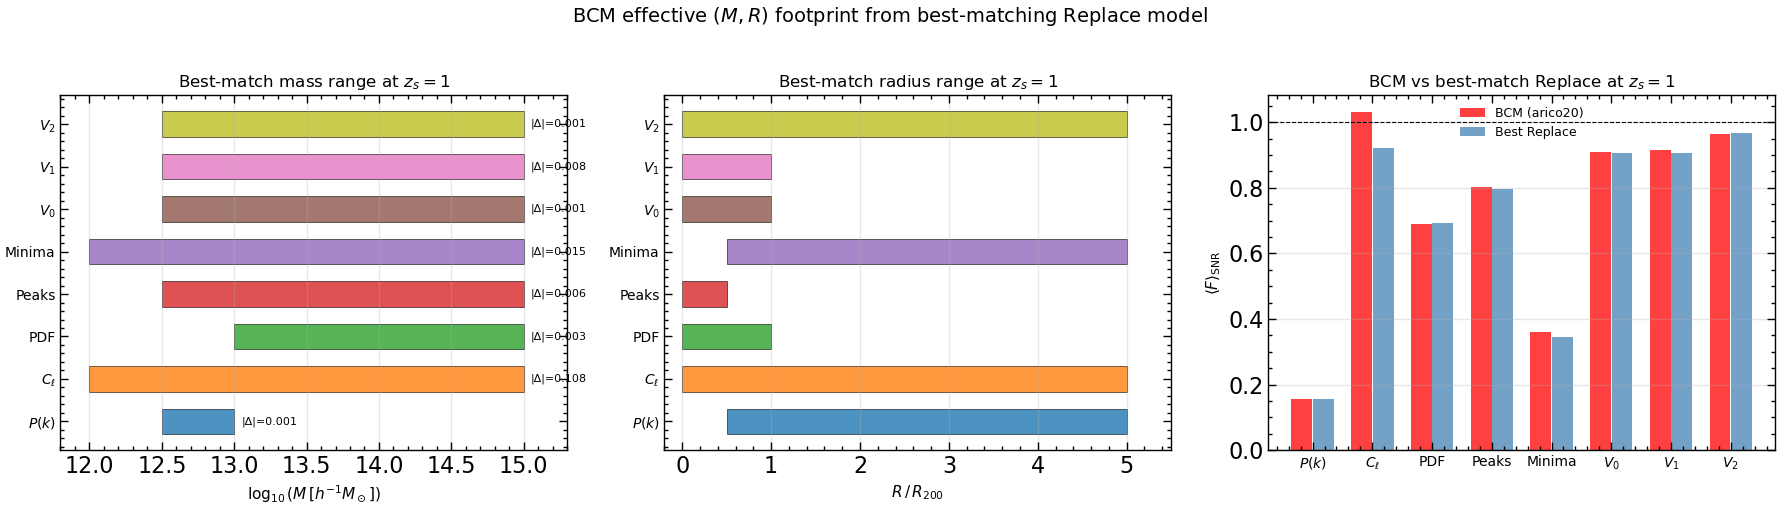

In [46]:
# ============================================================
# 8d. Visualize: Best-match (M,R) footprint per statistic
#     Left: mass range, Right: radius range
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

stat_colors = plt.cm.tab10(np.linspace(0, 0.8, len(STATISTICS)))

# --- Panel 1: Mass range of best-match model (at z=1) ---
ax = axes[0]
for i, stat in enumerate(STATISTICS):
    bm = best_match_z1[stat]
    ax.barh(i, bm['logMu'] - bm['logMl'], left=bm['logMl'],
            color=stat_colors[i], alpha=0.8, height=0.6, edgecolor='k', lw=0.5)
    ax.text(bm['logMu'] + 0.05, i, f"|Δ|={bm['dist']:.3f}", va='center', fontsize=8)
ax.set_yticks(range(len(STATISTICS)))
ax.set_yticklabels([STAT_LABELS[s] for s in STATISTICS], fontsize=10)
ax.set_xlabel(r'$\log_{10}(M\,[h^{-1}M_\odot])$', fontsize=11)
ax.set_title('Best-match mass range at $z_s=1$', fontsize=12)
ax.set_xlim(11.8, 15.3)
ax.grid(alpha=0.3, axis='x')

# --- Panel 2: Radius range of best-match model (at z=1) ---
ax = axes[1]
for i, stat in enumerate(STATISTICS):
    bm = best_match_z1[stat]
    ax.barh(i, bm['Ro'] - bm['Ri'], left=bm['Ri'],
            color=stat_colors[i], alpha=0.8, height=0.6, edgecolor='k', lw=0.5)
ax.set_yticks(range(len(STATISTICS)))
ax.set_yticklabels([STAT_LABELS[s] for s in STATISTICS], fontsize=10)
ax.set_xlabel(r'$R\,/\,R_{200}$', fontsize=11)
ax.set_title('Best-match radius range at $z_s=1$', fontsize=12)
ax.set_xlim(-0.2, 5.5)
ax.grid(alpha=0.3, axis='x')

# --- Panel 3: <F>_SNR comparison: BCM vs best-match Replace ---
ax = axes[2]
x = np.arange(len(STATISTICS))
bcm_vals_z1 = [bcm_scores[bcm_name][stat][weighting][z_match] for stat in STATISTICS]
rep_vals_z1 = [best_match_z1[stat]['F'] for stat in STATISTICS]
ax.bar(x - 0.18, bcm_vals_z1, 0.35, color='red', alpha=0.75, label=f'BCM ({bcm_name})')
ax.bar(x + 0.18, rep_vals_z1, 0.35, color='steelblue', alpha=0.75, label='Best Replace')
ax.axhline(1, color='k', ls='--', lw=0.8)
ax.axhline(0, color='k', ls='--', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([STAT_LABELS[s] for s in STATISTICS], fontsize=10)
ax.set_ylabel(r'$\langle F \rangle_{\rm SNR}$', fontsize=11)
ax.set_title('BCM vs best-match Replace at $z_s=1$', fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')

fig.suptitle('BCM effective $(M, R)$ footprint from best-matching Replace model',
             fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

In [47]:
# ============================================================
# 8e. Top-5 closest Replace models per statistic (at z=1)
#     Shows whether the match is unique or degenerate
# ============================================================

TOP_N = 5

print(f"Top-{TOP_N} closest Replace models per statistic at z_s ~ 1.0\n")
top5_per_stat = {}

for stat in STATISTICS:
    bcm_val = bcm_scores[bcm_name][stat][weighting][z_match]
    
    distances = []
    for mname in all_replace_scores:
        rval = all_replace_scores[mname][stat][weighting][z_match]
        if np.isfinite(rval):
            distances.append((abs(rval - bcm_val), mname, rval))
    distances.sort()
    
    top5_per_stat[stat] = distances[:TOP_N]
    
    print(f"  {STAT_LABELS[stat]}  (BCM = {bcm_val:.3f})")
    for rank, (d, mname, rval) in enumerate(distances[:TOP_N]):
        logMl, logMu, Ri, Ro = parse_model_params(mname)
        print(f"    #{rank+1}  M=[{logMl:.1f},{logMu:.1f}] R=[{Ri},{Ro}]  "
              f"F={rval:.3f}  |Δ|={d:.4f}")
    print()

Top-5 closest Replace models per statistic at z_s ~ 1.0

  $P(k)$  (BCM = 0.156)
    #1  M=[12.5,13.0] R=[0.5,5.0]  F=0.157  |Δ|=0.0009
    #2  M=[13.5,15.0] R=[0.0,3.0]  F=0.158  |Δ|=0.0022
    #3  M=[12.0,13.5] R=[0.5,3.0]  F=0.152  |Δ|=0.0039
    #4  M=[12.5,15.0] R=[0.5,3.0]  F=0.161  |Δ|=0.0044
    #5  M=[13.0,13.5] R=[0.0,1.0]  F=0.167  |Δ|=0.0106

  $C_\ell$  (BCM = 1.030)
    #1  M=[12.0,15.0] R=[0.0,5.0]  F=0.923  |Δ|=0.1079
    #2  M=[12.0,15.0] R=[0.0,3.0]  F=0.904  |Δ|=0.1262
    #3  M=[12.5,15.0] R=[0.0,5.0]  F=0.856  |Δ|=0.1745
    #4  M=[12.0,15.0] R=[0.0,1.0]  F=0.837  |Δ|=0.1931
    #5  M=[12.5,15.0] R=[0.0,3.0]  F=0.832  |Δ|=0.1989

  PDF  (BCM = 0.689)
    #1  M=[13.0,15.0] R=[0.0,1.0]  F=0.692  |Δ|=0.0030
    #2  M=[12.0,13.5] R=[0.0,5.0]  F=0.659  |Δ|=0.0301
    #3  M=[13.0,15.0] R=[0.0,0.5]  F=0.655  |Δ|=0.0341
    #4  M=[12.5,13.5] R=[0.0,5.0]  F=0.635  |Δ|=0.0540
    #5  M=[13.0,15.0] R=[0.0,3.0]  F=0.758  |Δ|=0.0685

  Peaks  (BCM = 0.803)
    #1  M=[12.5,15.0]

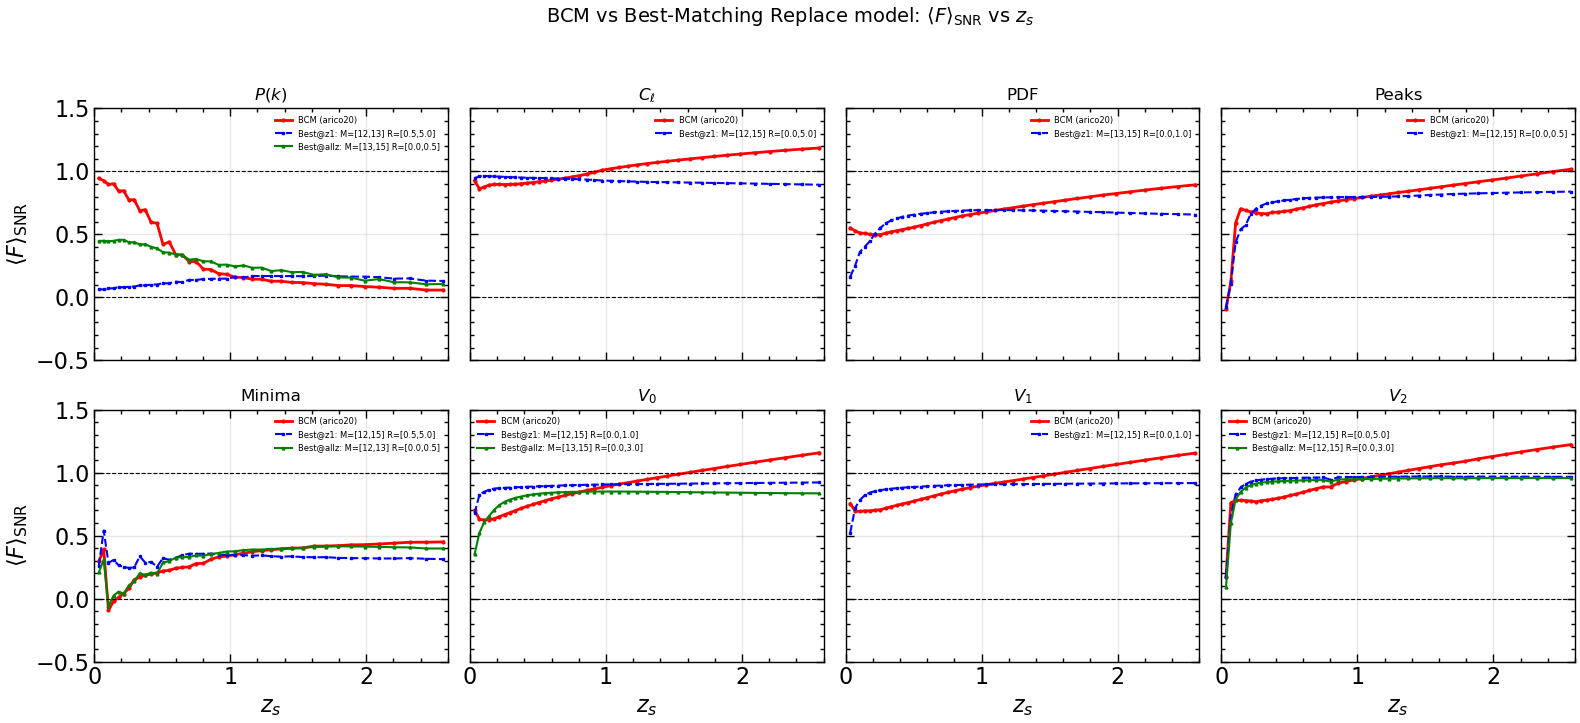

In [48]:
# ============================================================
# 8f. <F>_SNR vs redshift: BCM overlaid with its best-match Replace
#     per statistic — 8-panel grid
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True, sharey=True)
axes = axes.flatten()

for idx, stat in enumerate(STATISTICS):
    ax = axes[idx]
    
    # BCM
    F_bcm_z = bcm_scores[bcm_name][stat][weighting]
    ax.plot(REDSHIFTS_ALL, F_bcm_z, 'r-o', lw=2, ms=2, label=f'BCM ({bcm_name})')
    
    # Best match at z=1
    bm = best_match_z1[stat]
    F_rep_z = all_replace_scores[bm['name']][stat][weighting]
    logMl, logMu, Ri, Ro = bm['logMl'], bm['logMu'], bm['Ri'], bm['Ro']
    ax.plot(REDSHIFTS_ALL, F_rep_z, 'b--s', lw=1.5, ms=2,
            label=f'Best@z1: M=[{logMl:.0f},{logMu:.0f}] R=[{Ri},{Ro}]')
    
    # Best match over all z
    bma = best_match_allz[stat]
    if bma['name'] != bm['name']:
        F_rep_allz = all_replace_scores[bma['name']][stat][weighting]
        logMl2, logMu2, Ri2, Ro2 = bma['logMl'], bma['logMu'], bma['Ri'], bma['Ro']
        ax.plot(REDSHIFTS_ALL, F_rep_allz, 'g-^', lw=1.5, ms=2,
                label=f'Best@allz: M=[{logMl2:.0f},{logMu2:.0f}] R=[{Ri2},{Ro2}]')
    
    ax.axhline(0, color='k', ls='--', lw=0.8)
    ax.axhline(1, color='k', ls='--', lw=0.8)
    ax.set_xlim(0, 2.6)
    ax.set_ylim(-0.5, 1.5)
    ax.set_title(STAT_LABELS[stat], fontsize=12)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=6, loc='best')
    if idx >= 4:
        ax.set_xlabel(r'$z_s$')
    if idx % 4 == 0:
        ax.set_ylabel(r'$\langle F \rangle_{\rm SNR}$')

fig.suptitle(r'BCM vs Best-Matching Replace model: $\langle F \rangle_{\rm SNR}$ vs $z_s$',
             fontsize=14, y=1.04)
plt.tight_layout()
plt.show()

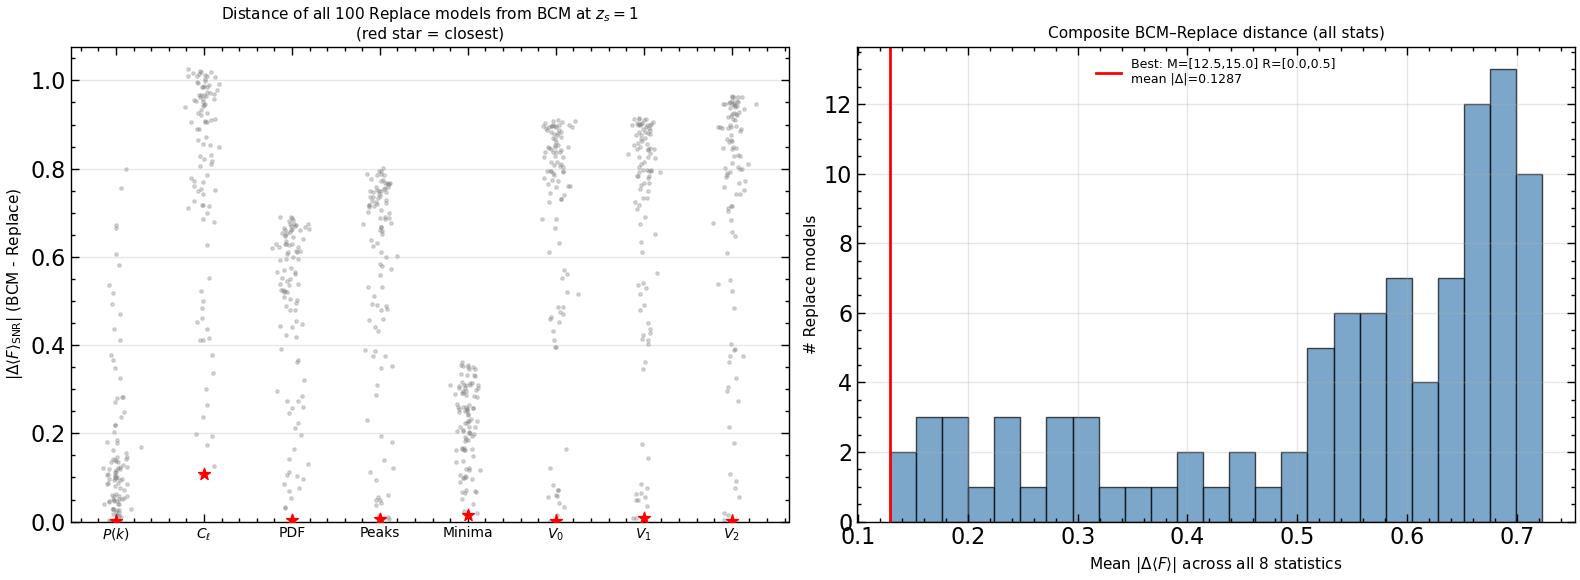


Best composite match (min mean |Δ| over all 8 stats):
  hydro_replace_Ml_3.16e12_Mu_1.00e15_Ri_0.0_Ro_0.5
  M=[12.5,15.0] R=[0.0,0.5]
  mean |Δ| = 0.1287


In [49]:
# ============================================================
# 8g. Heatmap of |Δ<F>| for ALL 100 models × 8 statistics
#     Shows the landscape of BCM–Replace distance
# ============================================================

# Build distance matrix: rows = models, cols = statistics
# Order models by (Ml, Mu, Ri, Ro) for structure
model_order = sorted(all_replace_scores.keys())
n_models = len(model_order)
n_stats = len(STATISTICS)

dist_matrix = np.full((n_models, n_stats), np.nan)
for i, mname in enumerate(model_order):
    for j, stat in enumerate(STATISTICS):
        bcm_val = bcm_scores[bcm_name][stat][weighting][z_match]
        rep_val = all_replace_scores[mname][stat][weighting][z_match]
        if np.isfinite(rep_val) and np.isfinite(bcm_val):
            dist_matrix[i, j] = abs(rep_val - bcm_val)

# Find per-column (per-stat) best model index
best_per_stat = np.nanargmin(dist_matrix, axis=0)

# Composite distance: mean |Δ| across all 8 stats
composite_dist = np.nanmean(dist_matrix, axis=1)
best_composite = np.nanargmin(composite_dist)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: per-statistic ranked distances (violin-like)
ax = axes[0]
for j, stat in enumerate(STATISTICS):
    col = dist_matrix[:, j]
    valid = col[np.isfinite(col)]
    # scatter all distances
    ax.scatter(np.full_like(valid, j) + np.random.normal(0, 0.08, len(valid)),
               valid, s=6, alpha=0.3, color='grey')
    # highlight best
    ax.scatter(j, col[best_per_stat[j]], s=80, color='red', marker='*', zorder=10)
ax.set_xticks(range(n_stats))
ax.set_xticklabels([STAT_LABELS[s] for s in STATISTICS], fontsize=10)
ax.set_ylabel(r'$|\Delta \langle F \rangle_{\rm SNR}|$ (BCM - Replace)', fontsize=11)
ax.set_title('Distance of all 100 Replace models from BCM at $z_s=1$\n(red star = closest)', fontsize=11)
ax.set_ylim(bottom=0)
ax.grid(alpha=0.3, axis='y')

# Right: Composite distance distribution
ax2 = axes[1]
ax2.hist(composite_dist[np.isfinite(composite_dist)], bins=25, color='steelblue',
         alpha=0.7, edgecolor='k', lw=0.5)
best_comp_name = model_order[best_composite]
logMl, logMu, Ri, Ro = parse_model_params(best_comp_name)
ax2.axvline(composite_dist[best_composite], color='red', lw=2,
            label=f'Best: M=[{logMl:.1f},{logMu:.1f}] R=[{Ri},{Ro}]\n'
                  f'mean |Δ|={composite_dist[best_composite]:.4f}')
ax2.set_xlabel(r'Mean $|\Delta \langle F \rangle|$ across all 8 statistics', fontsize=11)
ax2.set_ylabel('# Replace models', fontsize=11)
ax2.set_title('Composite BCM–Replace distance (all stats)', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print best composite model
print(f"\nBest composite match (min mean |Δ| over all 8 stats):")
print(f"  {best_comp_name}")
print(f"  M=[{logMl:.1f},{logMu:.1f}] R=[{Ri},{Ro}]")
print(f"  mean |Δ| = {composite_dist[best_composite]:.4f}")

Model classification: {'cross': 42, 'cum_radius': 18, 'cum_mass': 28, 'cum_both': 12}


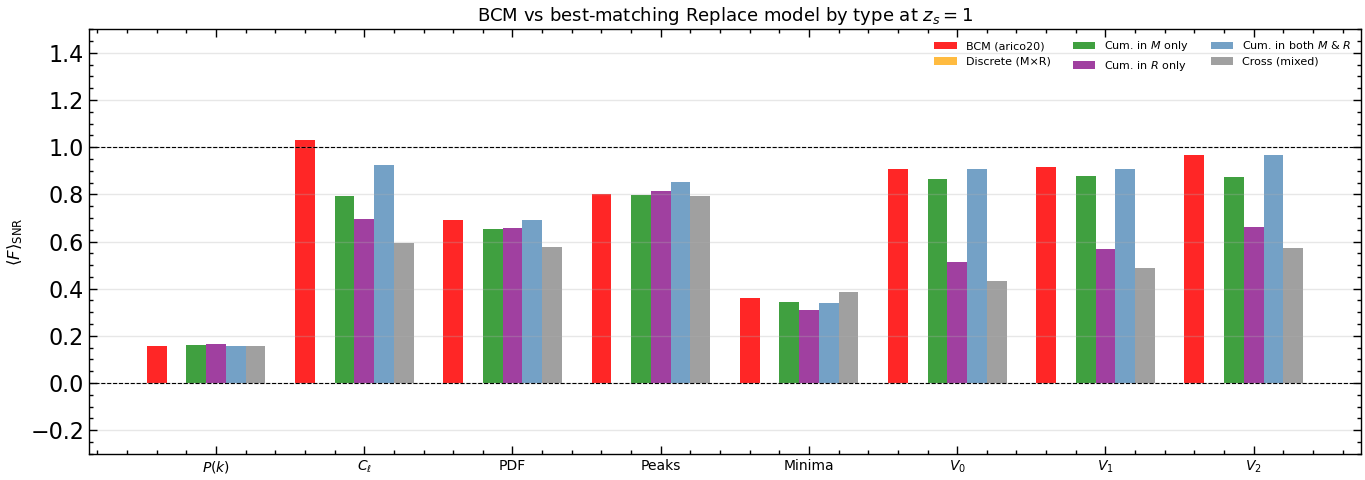

In [51]:
# ============================================================
# 8h. Classify models as discrete / cumulative / cross
#     and show best-match by model TYPE per statistic
# ============================================================

def classify_model(mname):
    """Classify a Replace model as discrete, cumulative-in-mass,
    cumulative-in-radius, or cross (one axis cumulative, one discrete)."""
    logMl, logMu, Ri, Ro = parse_model_params(mname)
    
    # Discrete mass bins: width = 0.5 in log10(M)
    disc_mass_edges = [(12.0, 12.5), (12.5, 13.0), (13.0, 13.5), (13.5, 15.0)]
    # Discrete radius bins
    disc_rad_edges = [(0.0, 0.5), (0.5, 1.0), (1.0, 3.0), (3.0, 5.0)]
    
    m_disc = (logMl, logMu) in disc_mass_edges
    r_disc = (Ri, Ro) in disc_rad_edges
    
    # Cumulative-in-mass: Mu = 15 and spans multiple bins
    m_cum = (logMu == 15.0 and not m_disc)
    # Cumulative-in-radius: Ri = 0 and spans multiple bins
    r_cum = (Ri == 0.0 and not r_disc)
    
    if m_disc and r_disc:
        return 'discrete'
    elif m_cum and r_cum:
        return 'cum_both'
    elif m_cum:
        return 'cum_mass'
    elif r_cum:
        return 'cum_radius'
    else:
        return 'cross'

# Classify all models
model_classes = {mname: classify_model(mname) for mname in model_order}
class_counts = {}
for c in model_classes.values():
    class_counts[c] = class_counts.get(c, 0) + 1
print("Model classification:", class_counts)

# --- Find best match per class per statistic ---
CLASS_NAMES = ['discrete', 'cum_mass', 'cum_radius', 'cum_both', 'cross']
CLASS_LABELS = {
    'discrete': 'Discrete (M×R)',
    'cum_mass': r'Cum. in $M$ only',
    'cum_radius': r'Cum. in $R$ only',
    'cum_both': r'Cum. in both $M$ & $R$',
    'cross': 'Cross (mixed)',
}

best_by_class = {}  # {class: {stat: (name, F, dist)}}
for cls in CLASS_NAMES:
    best_by_class[cls] = {}
    members = [m for m in model_order if model_classes[m] == cls]
    for stat in STATISTICS:
        bcm_val = bcm_scores[bcm_name][stat][weighting][z_match]
        best_name, best_dist, best_val = None, np.inf, np.nan
        for mname in members:
            rval = all_replace_scores[mname][stat][weighting][z_match]
            if np.isfinite(rval):
                d = abs(rval - bcm_val)
                if d < best_dist:
                    best_dist, best_name, best_val = d, mname, rval
        best_by_class[cls][stat] = (best_name, best_val, best_dist)

# --- Plot grouped bar chart ---
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(STATISTICS))
n_cls = len(CLASS_NAMES)
width = 0.8 / (n_cls + 1)
cls_colors = {'discrete': 'orange', 'cum_mass': 'green', 'cum_radius': 'purple',
              'cum_both': 'steelblue', 'cross': 'grey'}

# BCM bars
bcm_vals = [bcm_scores[bcm_name][stat][weighting][z_match] for stat in STATISTICS]
ax.bar(x - 0.4, bcm_vals, width, color='red', alpha=0.85, label=f'BCM ({bcm_name})')

for ci, cls in enumerate(CLASS_NAMES):
    vals = [best_by_class[cls][stat][1] for stat in STATISTICS]
    ax.bar(x - 0.4 + (ci + 1) * width, vals, width,
           color=cls_colors[cls], alpha=0.75, label=CLASS_LABELS[cls])

ax.axhline(1, color='k', ls='--', lw=0.8)
ax.axhline(0, color='k', ls='--', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([STAT_LABELS[s] for s in STATISTICS], fontsize=10)
ax.set_ylabel(r'$\langle F \rangle_{\rm SNR}$', fontsize=12)
ax.set_title(r'BCM vs best-matching Replace model by type at $z_s = 1$', fontsize=13)
ax.legend(fontsize=8, ncol=3, loc='upper right')
ax.grid(alpha=0.3, axis='y')
ax.set_ylim(-0.3, 1.5)
plt.tight_layout()
plt.show()

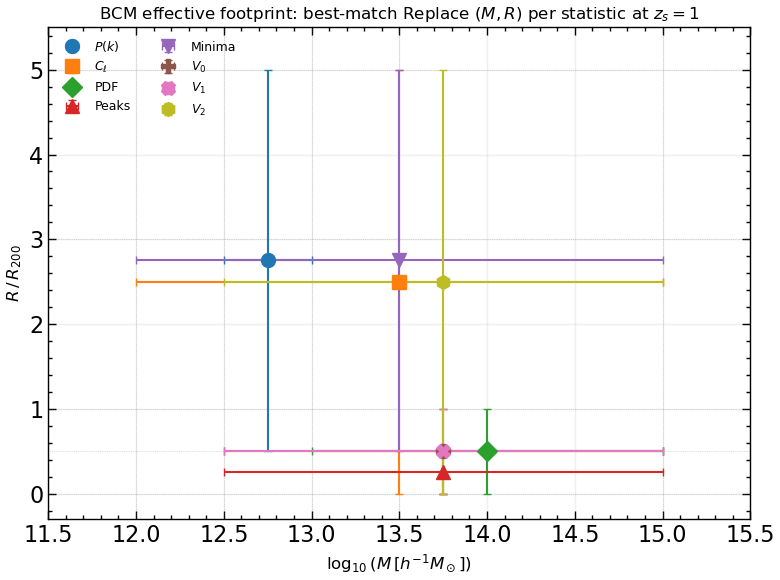

In [52]:
# ============================================================
# 8i. (M, R) scatter: where does the best-match fall 
#     for each statistic? — the BCM "fingerprint"
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))

stat_markers = {
    'Pk': 'o', 'Cl': 's', 'pdf': 'D', 'peaks': '^',
    'minima': 'v', 'V0': 'P', 'V1': 'X', 'V2': 'h'
}
stat_colors_sc = plt.cm.tab10(np.linspace(0, 0.8, len(STATISTICS)))

for i, stat in enumerate(STATISTICS):
    bm = best_match_z1[stat]
    # Plot at centroid of mass and radius range
    m_center = (bm['logMl'] + bm['logMu']) / 2
    r_center = (bm['Ri'] + bm['Ro']) / 2
    m_half = (bm['logMu'] - bm['logMl']) / 2
    r_half = (bm['Ro'] - bm['Ri']) / 2
    
    ax.errorbar(m_center, r_center, xerr=m_half, yerr=r_half,
                fmt=stat_markers[stat], color=stat_colors_sc[i], ms=10,
                capsize=3, lw=1.5, label=STAT_LABELS[stat], zorder=10)

# Show mass/radius bin edges
for me in MASS_EDGES:
    ax.axvline(me, color='grey', ls=':', lw=0.5, alpha=0.5)
for re in RADIUS_EDGES:
    ax.axhline(re, color='grey', ls=':', lw=0.5, alpha=0.5)

ax.set_xlabel(r'$\log_{10}(M\,[h^{-1}M_\odot])$', fontsize=12)
ax.set_ylabel(r'$R\,/\,R_{200}$', fontsize=12)
ax.set_title(r'BCM effective footprint: best-match Replace $(M, R)$ per statistic at $z_s=1$',
             fontsize=12)
ax.legend(fontsize=9, ncol=2, loc='upper left')
ax.set_xlim(11.5, 15.5)
ax.set_ylim(-0.3, 5.5)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [53]:
# ============================================================
# 8j. Summary table: best composite + per-stat best at z=1
#     and full redshift average
# ============================================================

print(f"{'='*100}")
print(f"  SUMMARY: BCM best-matching Replace model per statistic")
print(f"{'='*100}")
print(f"\n{'Stat':<10} {'--- At z_s=1 ---':<45} {'--- All z ---':<45}")
print(f"{'':10} {'M range':>12} {'R range':>10} {'|Δ|':>6}   {'M range':>12} {'R range':>10} {'mean|Δ|':>8}")
print('-' * 100)

for stat in STATISTICS:
    bm1 = best_match_z1[stat]
    bma = best_match_allz[stat]
    m1 = f"[{bm1['logMl']:.1f},{bm1['logMu']:.1f}]"
    r1 = f"[{bm1['Ri']},{bm1['Ro']}]"
    ma = f"[{bma['logMl']:.1f},{bma['logMu']:.1f}]"
    ra = f"[{bma['Ri']},{bma['Ro']}]"
    print(f"{STAT_LABELS[stat]:<10} {m1:>12} {r1:>10} {bm1['dist']:>6.3f}   {ma:>12} {ra:>10} {bma['mean_dist']:>8.4f}")

print(f"\nBest COMPOSITE model (minimising mean |Δ| over all 8 stats at z=1):")
print(f"  {best_comp_name}")
print(f"  M=[{parse_model_params(best_comp_name)[0]:.1f},{parse_model_params(best_comp_name)[1]:.1f}]  "
      f"R=[{parse_model_params(best_comp_name)[2]},{parse_model_params(best_comp_name)[3]}]")
print(f"  mean |Δ| = {composite_dist[best_composite]:.4f}")

# Check self-consistency: do all stats agree on the same model?
unique_z1 = set(best_match_z1[s]['name'] for s in STATISTICS)
print(f"\n# unique best-match models at z=1: {len(unique_z1)} / {len(STATISTICS)} statistics")
if len(unique_z1) > 1:
    print("→ BCM is NOT self-consistent: different statistics prefer different (M,R) footprints")
else:
    print("→ BCM IS self-consistent: all statistics agree on the same Replace model")

  SUMMARY: BCM best-matching Replace model per statistic

Stat       --- At z_s=1 ---                              --- All z ---                                
                M range    R range    |Δ|        M range    R range  mean|Δ|
----------------------------------------------------------------------------------------------------
$P(k)$      [12.5,13.0]  [0.5,5.0]  0.001    [13.0,15.0]  [0.0,0.5]   0.1500
$C_\ell$    [12.0,15.0]  [0.0,5.0]  0.108    [12.0,15.0]  [0.0,5.0]   0.1127
PDF         [13.0,15.0]  [0.0,1.0]  0.003    [13.0,15.0]  [0.0,1.0]   0.1002
Peaks       [12.5,15.0]  [0.0,0.5]  0.006    [12.5,15.0]  [0.0,0.5]   0.0696
Minima      [12.0,15.0]  [0.5,5.0]  0.015    [12.5,13.5]  [0.0,0.5]   0.0332
$V_0$       [12.5,15.0]  [0.0,1.0]  0.001    [13.0,15.0]  [0.0,3.0]   0.1166
$V_1$       [12.5,15.0]  [0.0,1.0]  0.008    [12.5,15.0]  [0.0,1.0]   0.1031
$V_2$       [12.5,15.0]  [0.0,5.0]  0.001    [12.5,15.0]  [0.0,3.0]   0.1049

Best COMPOSITE model (minimising mean |Δ| ov

/tmp/ipykernel_715013/1294944448.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


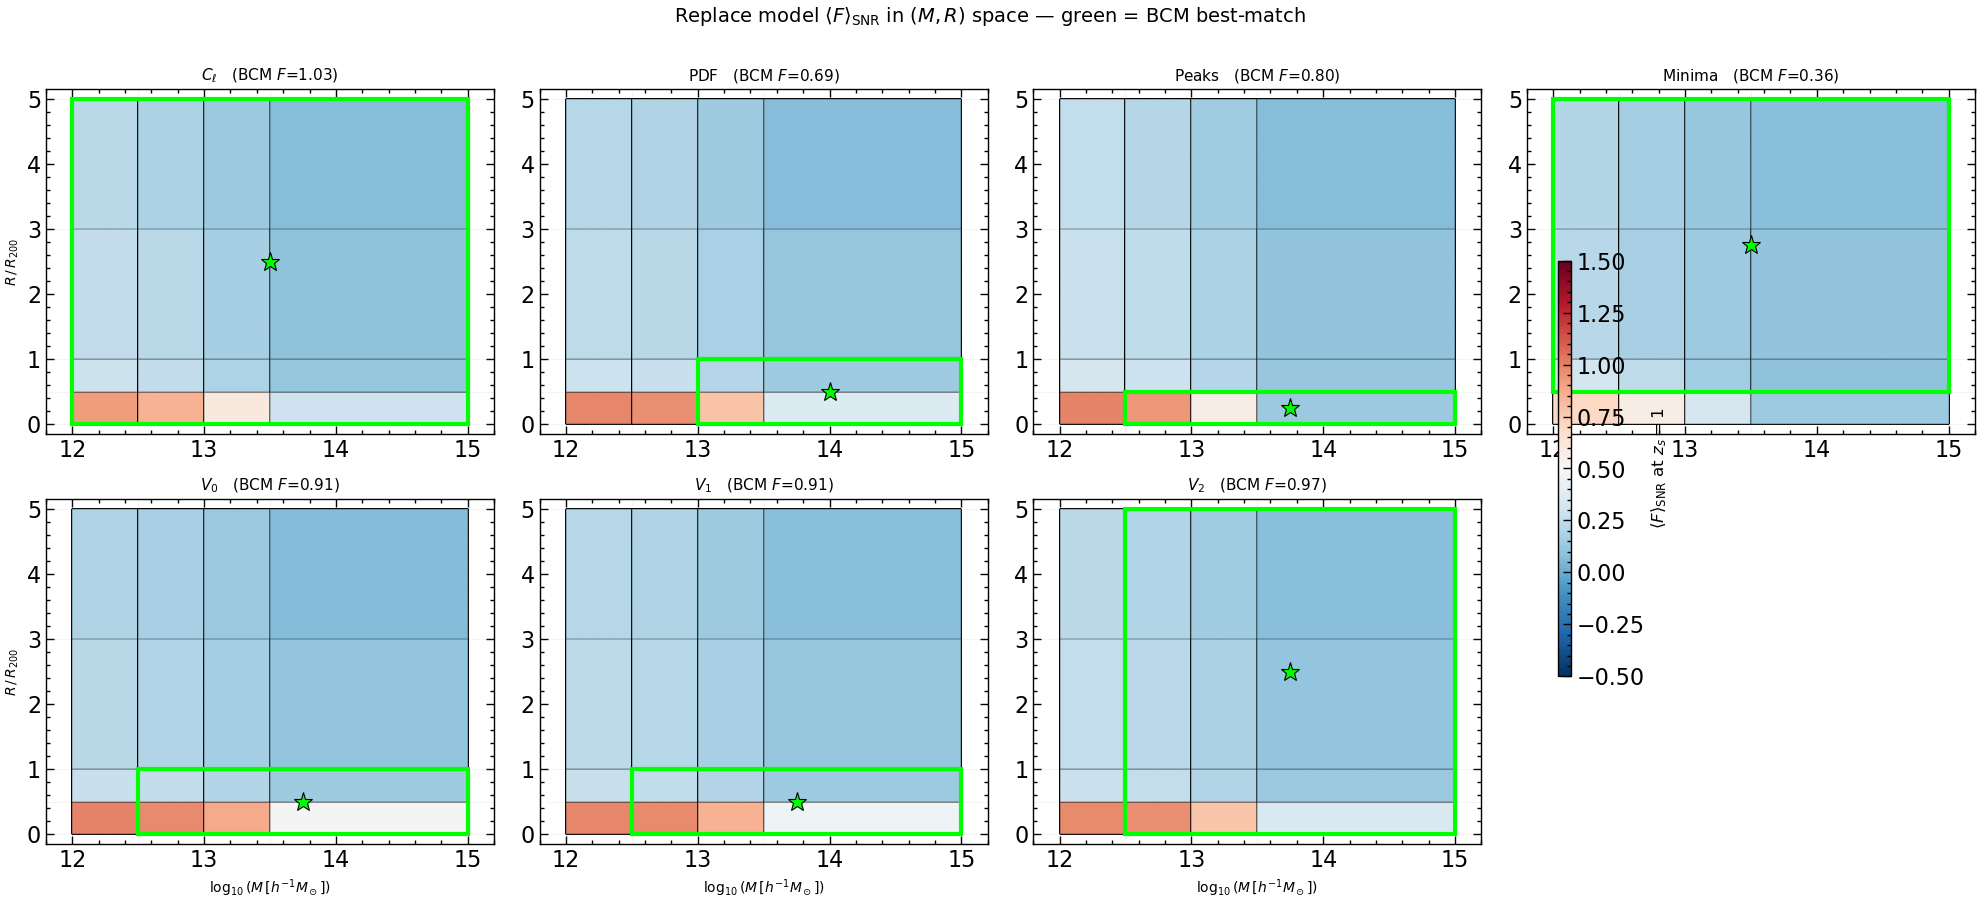

In [54]:
# ============================================================
# 8k. (M, R) scatter colored by <F>_SNR at z=1
#     One panel per non-Pk statistic; BCM best-match shown as star
# ============================================================

from matplotlib.patches import Rectangle
from matplotlib.colors import TwoSlopeNorm

STATS_NO_PK = [s for s in STATISTICS if s != 'Pk']
z_match = 23
weighting = 'snr_weighted_F'

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

# Shared colorbar normalization centred on F=1
norm = TwoSlopeNorm(vmin=-0.5, vcenter=0.5, vmax=1.5)
cmap = plt.cm.RdBu_r

for idx, stat in enumerate(STATS_NO_PK):
    ax = axes[idx]
    bcm_val = bcm_scores[bcm_name][stat][weighting][z_match]

    # --- Plot each Replace model as a coloured rectangle ---
    for mname in all_replace_scores:
        logMl, logMu, Ri, Ro = parse_model_params(mname)
        F_val = all_replace_scores[mname][stat][weighting][z_match]
        if not np.isfinite(F_val):
            continue
        rect = Rectangle((logMl, Ri), logMu - logMl, Ro - Ri,
                          facecolor=cmap(norm(F_val)), edgecolor='k',
                          lw=0.3, alpha=0.85)
        ax.add_patch(rect)

    # --- Highlight the BCM best-match model with a thick border ---
    bm = best_match_z1[stat]
    rect_bm = Rectangle((bm['logMl'], bm['Ri']),
                         bm['logMu'] - bm['logMl'], bm['Ro'] - bm['Ri'],
                         facecolor='none', edgecolor='lime', lw=3, zorder=10)
    ax.add_patch(rect_bm)

    # Star at the centroid of the best-match cell
    m_c = (bm['logMl'] + bm['logMu']) / 2
    r_c = (bm['Ri'] + bm['Ro']) / 2
    ax.plot(m_c, r_c, '*', color='lime', ms=14, mec='k', mew=0.8, zorder=11)

    ax.set_xlim(11.8, 15.2)
    ax.set_ylim(-0.15, 5.15)
    ax.set_title(f'{STAT_LABELS[stat]}   (BCM $F$={bcm_val:.2f})', fontsize=11)

    # Grid lines at bin edges
    for me in MASS_EDGES:
        ax.axvline(me, color='grey', ls=':', lw=0.4, alpha=0.4)
    for re in RADIUS_EDGES:
        ax.axhline(re, color='grey', ls=':', lw=0.4, alpha=0.4)

    if idx >= 4:
        ax.set_xlabel(r'$\log_{10}(M\,[h^{-1}M_\odot])$', fontsize=10)
    if idx % 4 == 0:
        ax.set_ylabel(r'$R\,/\,R_{200}$', fontsize=10)

# Hide the last panel if we have 7 stats
if len(STATS_NO_PK) < 8:
    for extra in range(len(STATS_NO_PK), 8):
        axes[extra].axis('off')

# Shared colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.tolist(), shrink=0.6, aspect=30, pad=0.02)
cbar.set_label(r'$\langle F \rangle_{\rm SNR}$ at $z_s=1$', fontsize=12)

fig.suptitle(r'Replace model $\langle F \rangle_{\rm SNR}$ in $(M, R)$ space — '
             r'green = BCM best-match',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

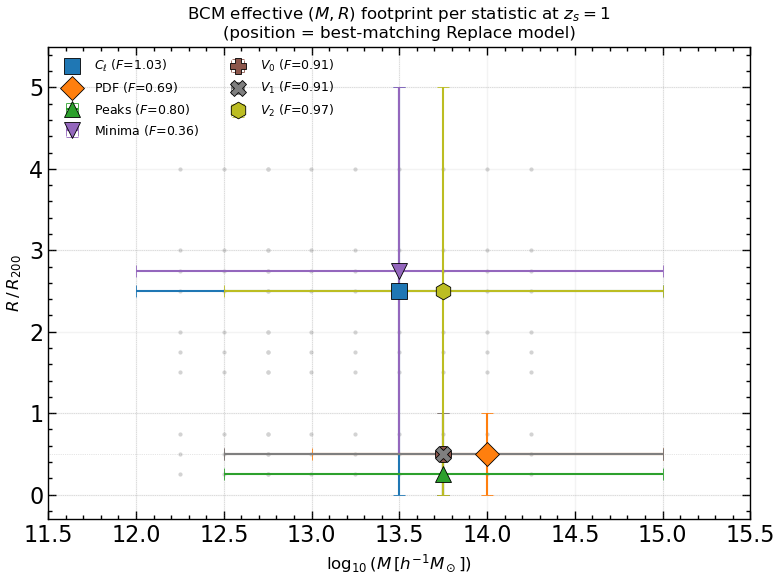

In [55]:
# ============================================================
# 8l. Single scatter: BCM best-match (M, R) per statistic
#     Marker color = BCM <F>_SNR, position = best-matching 
#     Replace model's (M, R) bin centroid
# ============================================================

stat_markers = {
    'Cl': 's', 'pdf': 'D', 'peaks': '^',
    'minima': 'v', 'V0': 'P', 'V1': 'X', 'V2': 'h'
}

fig, ax = plt.subplots(figsize=(8, 6))

# Background: faint grid of all 100 model centroids
for mname in all_replace_scores:
    logMl, logMu, Ri, Ro = parse_model_params(mname)
    ax.plot((logMl + logMu) / 2, (Ri + Ro) / 2,
            '.', color='lightgrey', ms=4, zorder=1)

# BCM best-match per statistic
for i, stat in enumerate(STATS_NO_PK):
    bm = best_match_z1[stat]
    m_c = (bm['logMl'] + bm['logMu']) / 2
    r_c = (bm['Ri'] + bm['Ro']) / 2
    m_half = (bm['logMu'] - bm['logMl']) / 2
    r_half = (bm['Ro'] - bm['Ri']) / 2
    bcm_F_val = bcm_scores[bcm_name][stat][weighting][z_match]

    ax.errorbar(m_c, r_c, xerr=m_half, yerr=r_half,
                fmt=stat_markers[stat], color=plt.cm.tab10(i / 7),
                ms=12, capsize=4, lw=1.5, mec='k', mew=0.6, zorder=10,
                label=f'{STAT_LABELS[stat]} ($F$={bcm_F_val:.2f})')

# Bin edges
for me in MASS_EDGES:
    ax.axvline(me, color='grey', ls=':', lw=0.5, alpha=0.4)
for re in RADIUS_EDGES:
    ax.axhline(re, color='grey', ls=':', lw=0.5, alpha=0.4)

ax.set_xlabel(r'$\log_{10}(M\,[h^{-1}M_\odot])$', fontsize=12)
ax.set_ylabel(r'$R\,/\,R_{200}$', fontsize=12)
ax.set_title(r'BCM effective $(M, R)$ footprint per statistic at $z_s=1$'
             '\n(position = best-matching Replace model)', fontsize=12)
ax.legend(fontsize=9, ncol=2, loc='upper left', framealpha=0.9)
ax.set_xlim(11.5, 15.5)
ax.set_ylim(-0.3, 5.5)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

In [56]:
# ============================================================
# 8m. Full 11×11 tiled grid of <F>_SNR at z=1 for each statistic
#     with BCM best-match cell highlighted
#
# Layout per axis (11 entries):
#   Discrete (4) | Cross (3) | Cumulative (4, corner repeated)
# ============================================================

# --- Axis orderings: discrete | cross | cumulative ---
# Mass: high mass at top within each block
mass_bins_11 = [
    # Discrete (exclusive bins)
    (13.5, 15.0),   # corner tile
    (13.0, 13.5),
    (12.5, 13.0),
    (12.0, 12.5),
    # Cross (span >1 discrete bin but not full cumulative)
    (12.5, 13.5),
    (12.0, 13.5),
    (12.0, 13.0),
    # Cumulative (Mu = 15, corner repeated)
    (13.5, 15.0),   # corner REPEATED
    (13.0, 15.0),
    (12.5, 15.0),
    (12.0, 15.0),
]

radius_bins_11 = [
    # Discrete (exclusive bins)
    (0.0, 0.5),     # corner tile
    (0.5, 1.0),
    (1.0, 3.0),
    (3.0, 5.0),
    # Cross
    (0.5, 3.0),
    (0.5, 5.0),
    (1.0, 5.0),
    # Cumulative (Ri = 0, corner repeated)
    (0.0, 0.5),     # corner REPEATED
    (0.0, 1.0),
    (0.0, 3.0),
    (0.0, 5.0),
]

# Tick labels
def mass_label(M_lo, M_hi):
    hi = r"$\infty$" if M_hi == 15.0 else rf"$10^{{{M_hi:.1f}}}$"
    return rf"$10^{{{M_lo:.1f}}}$–{hi}"

mass_labels_11 = [mass_label(ml, mh) for ml, mh in mass_bins_11]
radius_labels_11 = [f"{ri}–{ro}" for ri, ro in radius_bins_11]

print(f"Grid: {len(mass_bins_11)} × {len(radius_bins_11)} = {len(mass_bins_11)*len(radius_bins_11)} cells")
print(f"Mass axis: {len(mass_bins_11)} entries  (4 discrete + 3 cross + 4 cumulative)")
print(f"Radius axis: {len(radius_bins_11)} entries")

Grid: 11 × 11 = 121 cells
Mass axis: 11 entries  (4 discrete + 3 cross + 4 cumulative)
Radius axis: 11 entries


/tmp/ipykernel_715013/2811403852.py:101: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 0.96])


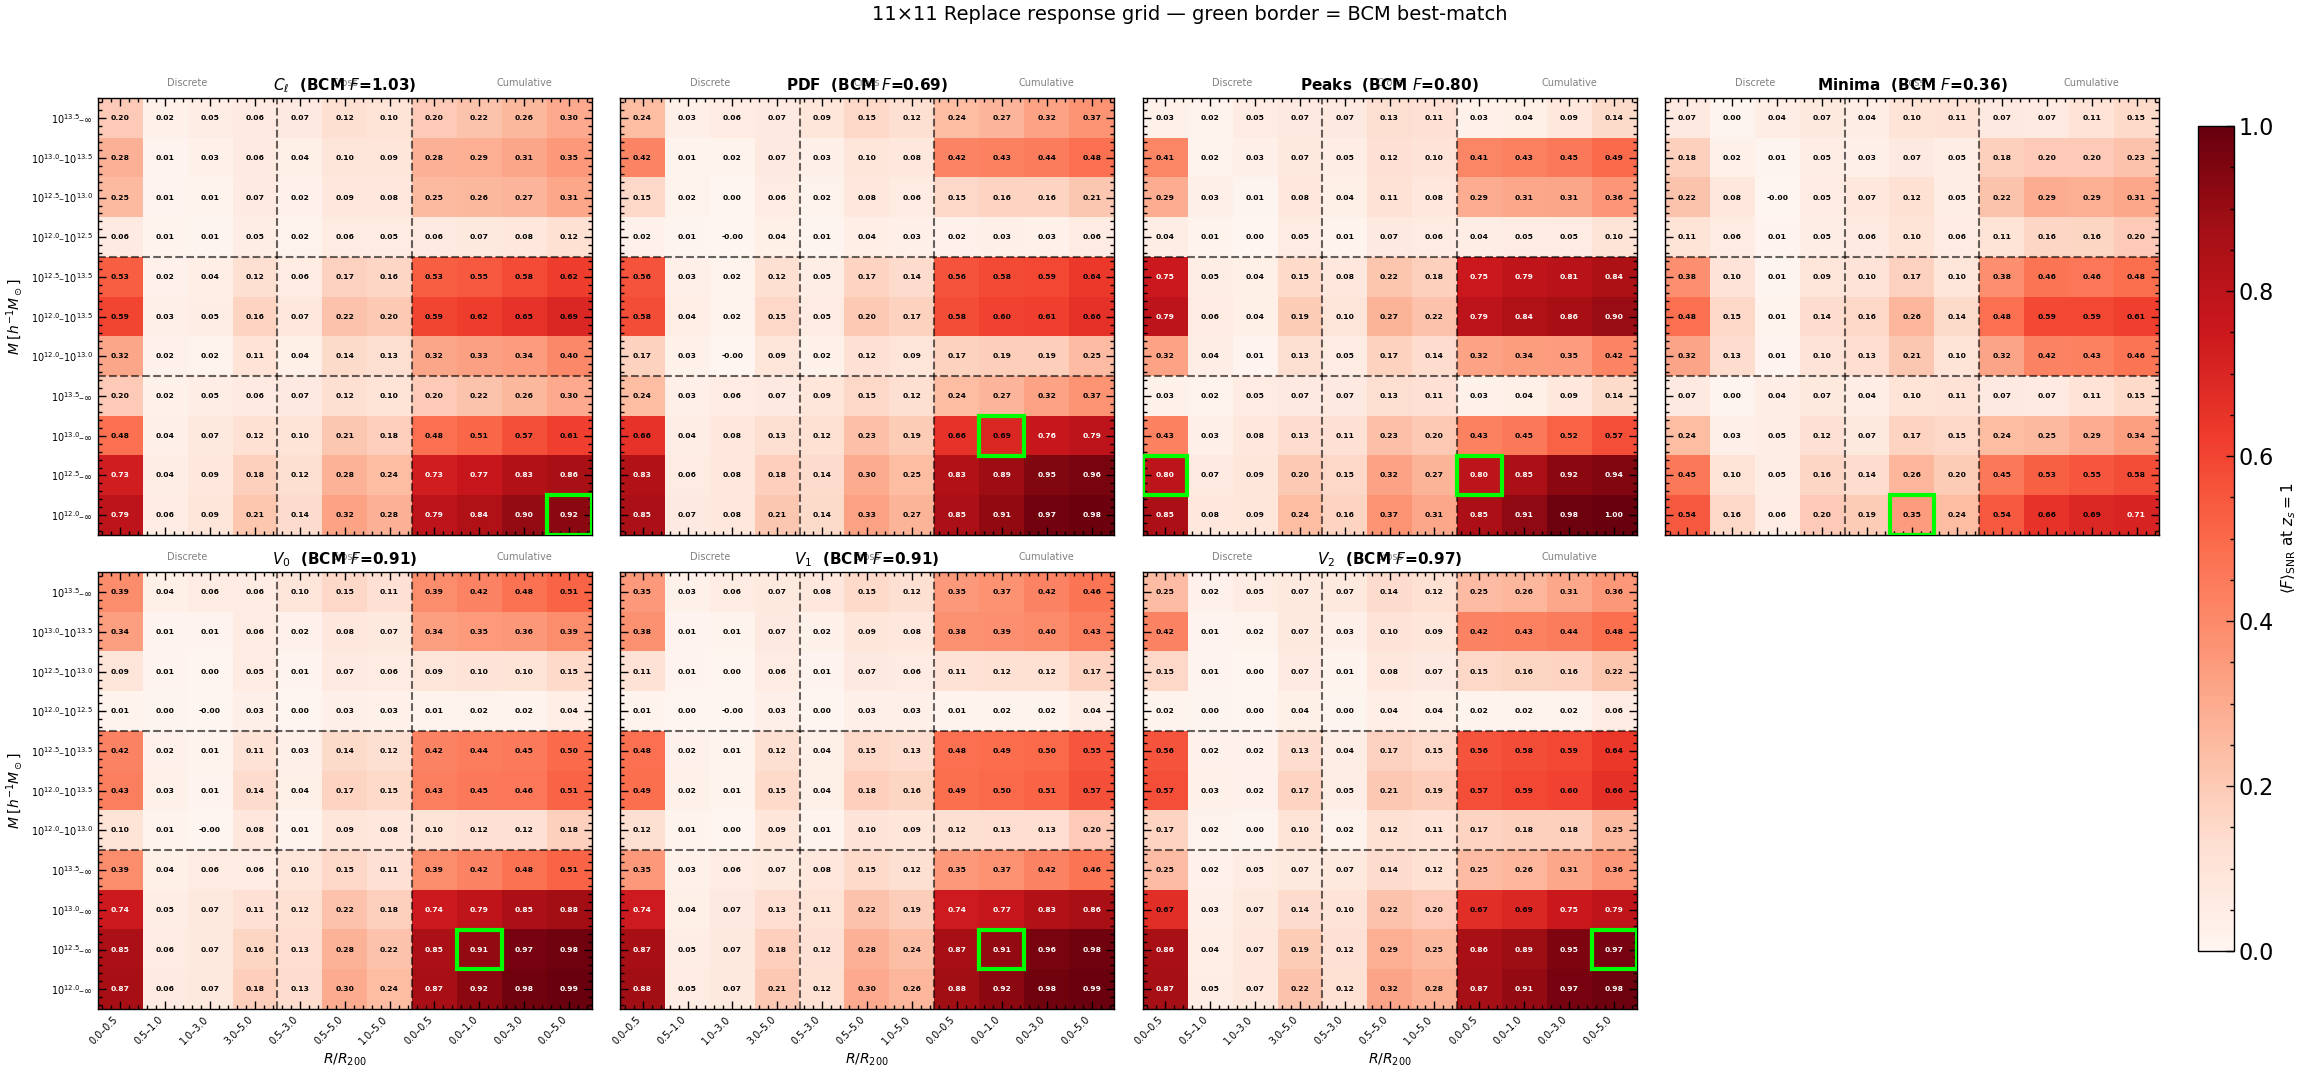

In [57]:
# ============================================================
# 8n. Multi-panel 11×11 heatmap with BCM best-match overlay
#     One panel per non-Pk statistic (7 panels)
# ============================================================
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle

STATS_NO_PK = [s for s in STATISTICS if s != 'Pk']

z_match = 23
weighting = 'snr_weighted_F'

fig, axes = plt.subplots(2, 4, figsize=(24, 11), sharex=True, sharey=True)
axes_flat = axes.flatten()

norm = TwoSlopeNorm(vmin=-0.0, vcenter=0.5, vmax=1.0)
cmap = plt.cm.Reds
images = []

for idx, stat in enumerate(STATS_NO_PK):
    ax = axes_flat[idx]
    bcm_val = bcm_scores[bcm_name][stat][weighting][z_match]

    # --- Build 11×11 F matrix ---
    F_matrix = np.full((len(mass_bins_11), len(radius_bins_11)), np.nan)
    for i, (M_lo, M_hi) in enumerate(mass_bins_11):
        for j, (R_in, R_out) in enumerate(radius_bins_11):
            mname = get_model_name(M_lo, M_hi, R_in, R_out)
            if mname in all_replace_scores:
                F_matrix[i, j] = all_replace_scores[mname][stat][weighting][z_match]

    # --- Heatmap ---
    im = ax.imshow(F_matrix, cmap=cmap, norm=norm, aspect='auto', origin='upper')
    images.append(im)

    # Annotate F values
    for i in range(F_matrix.shape[0]):
        for j in range(F_matrix.shape[1]):
            v = F_matrix[i, j]
            if np.isfinite(v):
                color = 'white' if v > 0.7 else 'black'
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        fontsize=5.5, color=color, fontweight='bold')

    # --- Mark BCM best-match cell ---
    bm = best_match_z1[stat]
    bm_M = (bm['logMl'], bm['logMu'])
    bm_R = (bm['Ri'], bm['Ro'])
    # Convert logMl/logMu back to (Ml_lin, Mu_lin) to match mass_bins_11 tuples
    bm_Mbin = (round(10**bm['logMl'], -1), round(10**bm['logMu'], -1))
    # Find grid position(s) of best-match
    for i, (M_lo, M_hi) in enumerate(mass_bins_11):
        for j, (R_in, R_out) in enumerate(radius_bins_11):
            mname = get_model_name(M_lo, M_hi, R_in, R_out)
            if mname == bm['name']:
                rect = Rectangle((j - 0.5, i - 0.5), 1, 1,
                                 facecolor='none', edgecolor='lime',
                                 lw=3, zorder=10)
                ax.add_patch(rect)

    # --- Region boundary lines ---
    ax.axhline(3.5, color='k', lw=1.5, ls='--', alpha=0.6)
    ax.axhline(6.5, color='k', lw=1.5, ls='--', alpha=0.6)
    ax.axvline(3.5, color='k', lw=1.5, ls='--', alpha=0.6)
    ax.axvline(6.5, color='k', lw=1.5, ls='--', alpha=0.6)

    ax.set_xticks(range(len(radius_bins_11)))
    ax.set_yticks(range(len(mass_bins_11)))

    if idx >= 4:
        ax.set_xticklabels(radius_labels_11, rotation=45, ha='right', fontsize=7)
        ax.set_xlabel(r'$R/R_{200}$', fontsize=10)
    if idx % 4 == 0:
        ax.set_yticklabels(mass_labels_11, fontsize=7)
        ax.set_ylabel(r'$M\;[h^{-1}M_\odot]$', fontsize=10)

    ax.set_title(f'{STAT_LABELS[stat]}  (BCM $F$={bcm_val:.2f})',
                 fontsize=11, fontweight='bold')

    # Region labels
    ax.text(1.5, -0.8, 'Discrete', ha='center', fontsize=7, color='grey',
            clip_on=False)
    ax.text(5, -0.8, 'Cross', ha='center', fontsize=7, color='grey',
            clip_on=False)
    ax.text(9, -0.8, 'Cumulative', ha='center', fontsize=7, color='grey',
            clip_on=False)

# Hide unused panel
if len(STATS_NO_PK) < 8:
    for extra in range(len(STATS_NO_PK), 8):
        axes_flat[extra].axis('off')

# Shared colorbar
fig.subplots_adjust(right=0.91)
cbar_ax = fig.add_axes([0.92, 0.12, 0.015, 0.75])
cbar = fig.colorbar(images[0], cax=cbar_ax)
cbar.set_label(r'$\langle F \rangle_{\rm SNR}$ at $z_s=1$', fontsize=11)

fig.suptitle(r'11×11 Replace response grid — green border = BCM best-match',
             fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0, 0.91, 0.96])
plt.show()

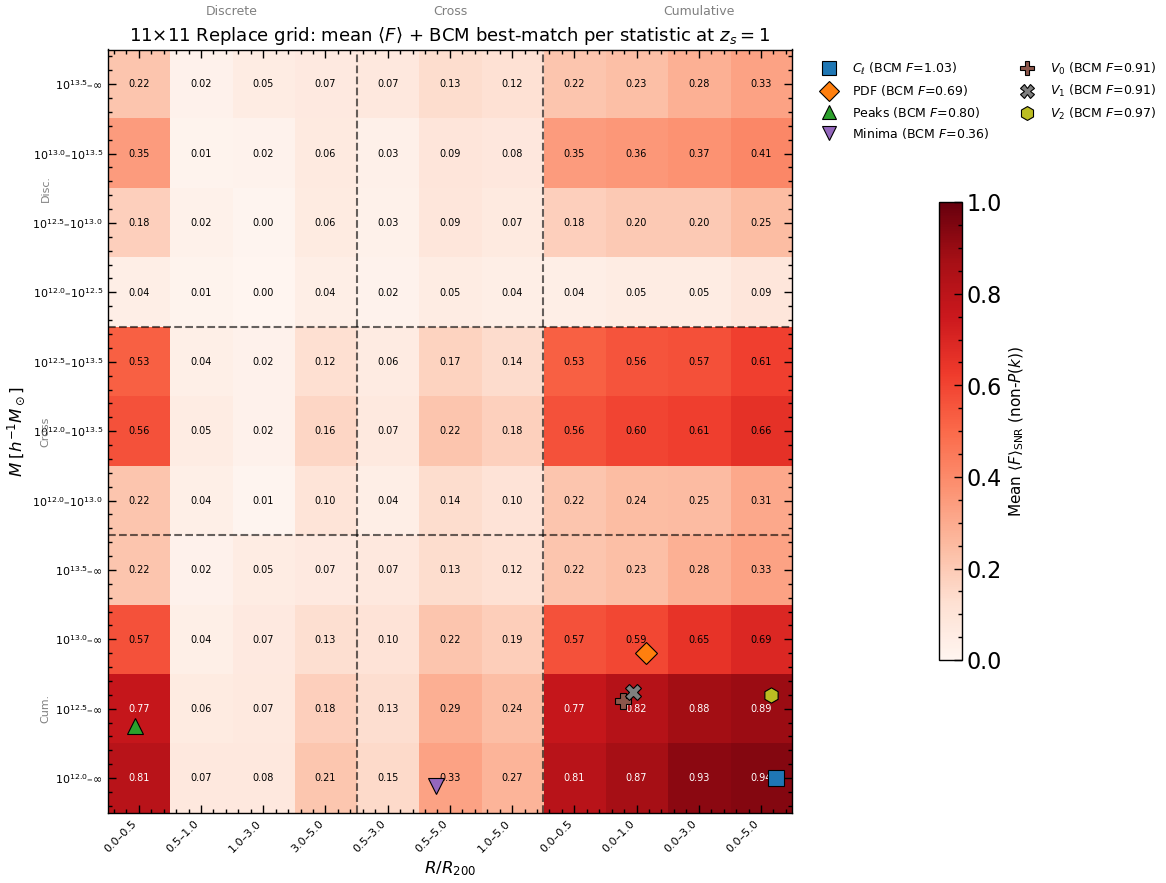

In [58]:
# ============================================================
# 8o. Combined single grid: ALL statistics' BCM best-match
#     on one 11×11 heatmap (coloured by mean F across stats)
# ============================================================

stat_markers = {
    'Cl': 's', 'pdf': 'D', 'peaks': '^',
    'minima': 'v', 'V0': 'P', 'V1': 'X', 'V2': 'h'
}
stat_colors_tab = {s: plt.cm.tab10(i / 7) for i, s in enumerate(STATS_NO_PK)}

# Mean F across all non-Pk statistics
F_mean_matrix = np.full((len(mass_bins_11), len(radius_bins_11)), np.nan)
for i, (M_lo, M_hi) in enumerate(mass_bins_11):
    for j, (R_in, R_out) in enumerate(radius_bins_11):
        mname = get_model_name(M_lo, M_hi, R_in, R_out)
        if mname in all_replace_scores:
            vals = [all_replace_scores[mname][s][weighting][z_match]
                    for s in STATS_NO_PK
                    if np.isfinite(all_replace_scores[mname][s][weighting][z_match])]
            if vals:
                F_mean_matrix[i, j] = np.mean(vals)

fig, ax = plt.subplots(figsize=(12, 9))

im = ax.imshow(F_mean_matrix, cmap='Reds', norm=norm, aspect='auto', origin='upper')

# Annotate
for i in range(F_mean_matrix.shape[0]):
    for j in range(F_mean_matrix.shape[1]):
        v = F_mean_matrix[i, j]
        if np.isfinite(v):
            color = 'white' if v > 0.7 else 'black'
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=7, color=color)

# Region boundaries
ax.axhline(3.5, color='k', lw=1.5, ls='--', alpha=0.6)
ax.axhline(6.5, color='k', lw=1.5, ls='--', alpha=0.6)
ax.axvline(3.5, color='k', lw=1.5, ls='--', alpha=0.6)
ax.axvline(6.5, color='k', lw=1.5, ls='--', alpha=0.6)

# --- Overlay BCM best-match for each statistic ---
# Small offsets to avoid overlapping markers on the same cell
n_stats = len(STATS_NO_PK)
angle_offsets = np.linspace(0, 2 * np.pi, n_stats, endpoint=False)
offset_r = 0.25  # scatter radius within cell

for si, stat in enumerate(STATS_NO_PK):
    bm = best_match_z1[stat]
    # Find grid position
    for i, (M_lo, M_hi) in enumerate(mass_bins_11):
        for j, (R_in, R_out) in enumerate(radius_bins_11):
            mname_grid = get_model_name(M_lo, M_hi, R_in, R_out)
            if mname_grid == bm['name']:
                dx = offset_r * np.cos(angle_offsets[si])
                dy = offset_r * np.sin(angle_offsets[si])
                ax.plot(j + dx, i + dy, stat_markers[stat],
                        color=stat_colors_tab[stat], ms=11,
                        mec='k', mew=0.8, zorder=10)
                break  # only mark first occurrence (could mark both for repeated corner)

# Legend for statistic markers
legend_handles = []
for stat in STATS_NO_PK:
    bcm_F_val = bcm_scores[bcm_name][stat][weighting][z_match]
    h = ax.plot([], [], stat_markers[stat], color=stat_colors_tab[stat],
                ms=10, mec='k', mew=0.8,
                label=f'{STAT_LABELS[stat]} (BCM $F$={bcm_F_val:.2f})')[0]
    legend_handles.append(h)

ax.set_xticks(range(len(radius_bins_11)))
ax.set_xticklabels(radius_labels_11, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(mass_bins_11)))
ax.set_yticklabels(mass_labels_11, fontsize=8)
ax.set_xlabel(r'$R/R_{200}$', fontsize=12)
ax.set_ylabel(r'$M\;[h^{-1}M_\odot]$', fontsize=12)

# Region text
ax.text(1.5, -1.0, 'Discrete', ha='center', fontsize=9, color='grey', clip_on=False)
ax.text(5, -1.0, 'Cross', ha='center', fontsize=9, color='grey', clip_on=False)
ax.text(9, -1.0, 'Cumulative', ha='center', fontsize=9, color='grey', clip_on=False)
ax.text(-1.5, 1.5, 'Disc.', ha='center', va='center', fontsize=8, color='grey',
        rotation=90, clip_on=False)
ax.text(-1.5, 5, 'Cross', ha='center', va='center', fontsize=8, color='grey',
        rotation=90, clip_on=False)
ax.text(-1.5, 9, 'Cum.', ha='center', va='center', fontsize=8, color='grey',
        rotation=90, clip_on=False)

ax.legend(handles=legend_handles, fontsize=9, ncol=2, loc='upper left',
          bbox_to_anchor=(1.02, 1.0), framealpha=0.95)

cbar = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.15)
cbar.set_label(r'Mean $\langle F \rangle_{\rm SNR}$ (non-$P(k)$)', fontsize=11)

ax.set_title(r'11×11 Replace grid: mean $\langle F \rangle$ + BCM best-match per statistic at $z_s=1$',
             fontsize=13)
plt.tight_layout()
plt.show()

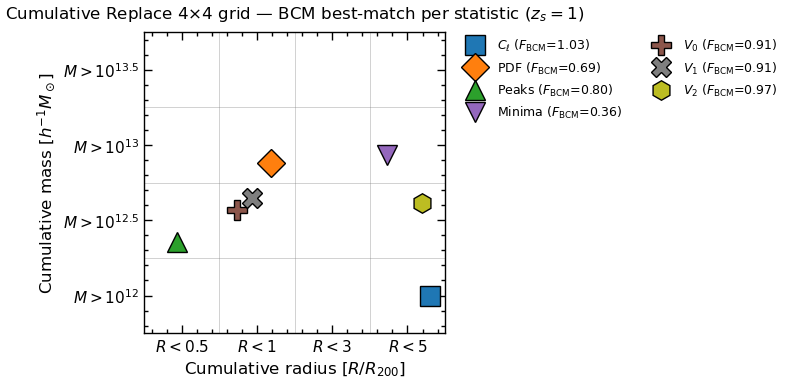


Stat       Grid (M,R)             Rep F   BCM F    |Δ|
-------------------------------------------------------
$C_\ell$   M>12.0 R<5.0          0.923   1.030  0.108
PDF        M>13.0 R<1.0          0.692   0.689  0.003
Peaks      M>12.5 R<0.5          0.797   0.803  0.006
Minima     M>13.0 R<5.0          0.339   0.360  0.020
$V_0$      M>12.5 R<1.0          0.908   0.909  0.001
$V_1$      M>12.5 R<1.0          0.907   0.915  0.008
$V_2$      M>12.5 R<5.0          0.966   0.966  0.001


In [60]:
# ============================================================
# 8p. Cumulative-only 4×4 grid with BCM best-match per statistic
# ============================================================

# Cumulative mass bins (Mu = 1e15) — high mass at top
cum_mass = [(13.5, 15.0), (13.0, 15.0), (12.5, 15.0), (12.0, 15.0)]
# Cumulative radius bins (Ri = 0)
cum_rad  = [(0.0, 0.5), (0.0, 1.0), (0.0, 3.0), (0.0, 5.0)]

cum_mass_labels = [
    r'$M > 10^{13.5}$',
    r'$M > 10^{13}$',
    r'$M > 10^{12.5}$',
    r'$M > 10^{12}$',
]
cum_rad_labels = [
    r'$R<0.5$',
    r'$R<1$',
    r'$R<3$',
    r'$R<5$',
]

STATS_NO_PK = [s for s in STATISTICS if s != 'Pk']
z_match = 23
weighting = 'snr_weighted_F'

# --- Build 4×4 F matrices and find best cumulative match per stat ---
best_cum = {}  # stat -> (i_row, j_col, model_name, F_val, dist)

for stat in STATS_NO_PK:
    bcm_val = bcm_scores[bcm_name][stat][weighting][z_match]
    best_d = np.inf
    for i, (Ml, Mu) in enumerate(cum_mass):
        for j, (Ri, Ro) in enumerate(cum_rad):
            mname = get_model_name(Ml, Mu, Ri, Ro)
            if mname not in all_replace_scores:
                continue
            fval = all_replace_scores[mname][stat][weighting][z_match]
            if not np.isfinite(fval):
                continue
            d = abs(fval - bcm_val)
            if d < best_d:
                best_d = d
                best_cum[stat] = (i, j, mname, fval, d)

# --- Plot: 4×4 heatmap + scatter markers ---
stat_markers = {
    'Cl': 's', 'pdf': 'D', 'peaks': '^',
    'minima': 'v', 'V0': 'P', 'V1': 'X', 'V2': 'h'
}
stat_colors_tab = {s: plt.cm.tab10(k / len(STATS_NO_PK))
                   for k, s in enumerate(STATS_NO_PK)}

fig, ax = plt.subplots(figsize=(7, 6))

# Plain grid (no heatmap colours)
ax.set_xlim(-0.5, 3.5)
ax.set_ylim(-0.5, 3.5)
ax.invert_yaxis()

# Draw grid lines
for g in range(5):
    ax.axhline(g - 0.5, color='grey', lw=0.5, alpha=0.5)
    ax.axvline(g - 0.5, color='grey', lw=0.5, alpha=0.5)

# Scatter: BCM best-match per stat, jittered slightly
n = len(STATS_NO_PK)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
jitter_r = 0.3

for k, stat in enumerate(STATS_NO_PK):
    i_row, j_col, mname, fval, dist = best_cum[stat]
    dx = jitter_r * np.cos(angles[k])
    dy = jitter_r * np.sin(angles[k])
    bcm_F_val = bcm_scores[bcm_name][stat][weighting][z_match]
    ax.plot(j_col + dx, i_row + dy, stat_markers[stat],
            color=stat_colors_tab[stat], ms=14, mec='k', mew=1.0, zorder=10,
            label=f'{STAT_LABELS[stat]} ($F_{{\\rm BCM}}$={bcm_F_val:.2f})')

ax.set_xticks(range(4))
ax.set_xticklabels(cum_rad_labels, fontsize=11)
ax.set_yticks(range(4))
ax.set_yticklabels(cum_mass_labels, fontsize=11)
ax.set_xlabel(r'Cumulative radius $[R/R_{200}]$', fontsize=12)
ax.set_ylabel(r'Cumulative mass $[h^{-1}M_\odot]$', fontsize=12)

ax.legend(fontsize=9, ncol=2, loc='upper left', bbox_to_anchor=(1.02, 1.02),
          framealpha=0.95)
ax.set_title(r'Cumulative Replace 4×4 grid — BCM best-match per statistic ($z_s=1$)',
             fontsize=12, pad=10)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

# Print summary
print(f"\n{'Stat':<10} {'Grid (M,R)':<20} {'Rep F':>7} {'BCM F':>7} {'|Δ|':>6}")
print('-' * 55)
for stat in STATS_NO_PK:
    i_row, j_col, mname, fval, dist = best_cum[stat]
    bcm_val = bcm_scores[bcm_name][stat][weighting][z_match]
    ml, mu = cum_mass[i_row]
    ri, ro = cum_rad[j_col]
    print(f"{STAT_LABELS[stat]:<10} M>{ml:.1f} R<{ro}  {' ':>5} {fval:>7.3f} {bcm_val:>7.3f} {dist:>6.3f}")

In [63]:
# ============================================================
# 8q. Best-match using FULL F(scale) profile vs scalar <F>
# ============================================================
# Instead of comparing a single SNR-weighted <F> number,
# we compare the bin-by-bin F(ℓ) or F(κ) profile at z_s ~ 1.
# Distance = RMS[ F_bcm(bin) - F_rep(bin) ]  over finite bins.

z_match = 23

# --- Profile-based best match: all 100 models ---
best_profile_z1 = {}          # stat -> {name, rms_dist, ...}
best_profile_cum = {}          # stat -> (i_row, j_col, mname, rms_dist)
all_profile_dist = {}          # stat -> {mname: rms_dist}

for stat in STATS_NO_PK:
    F_bcm = bcm_F[bcm_name][stat][z_match]    # shape (n_bins,)
    
    all_profile_dist[stat] = {}
    best_name, best_rms = None, np.inf
    
    for mname in all_replace_F:
        F_rep = all_replace_F[mname][stat][z_match]
        # Only compare bins where both are finite
        mask = np.isfinite(F_bcm) & np.isfinite(F_rep)
        if mask.sum() < 3:
            continue
        rms = np.sqrt(np.mean((F_bcm[mask] - F_rep[mask])**2))
        all_profile_dist[stat][mname] = rms
        if rms < best_rms:
            best_rms, best_name = rms, mname
    
    logMl, logMu, Ri, Ro = parse_model_params(best_name)
    best_profile_z1[stat] = {
        'name': best_name, 'rms_dist': best_rms,
        'logMl': logMl, 'logMu': logMu, 'Ri': Ri, 'Ro': Ro
    }
    
    # Also find best cumulative model by profile
    best_d_cum = np.inf
    for i, (Ml, Mu) in enumerate(cum_mass):
        for j, (Ri_c, Ro_c) in enumerate(cum_rad):
            mn = get_model_name(Ml, Mu, Ri_c, Ro_c)
            if mn in all_profile_dist[stat]:
                d = all_profile_dist[stat][mn]
                if d < best_d_cum:
                    best_d_cum = d
                    best_profile_cum[stat] = (i, j, mn, d)

# --- Comparison table: scalar <F> vs profile RMS ---
print(f"{'Stat':<10} {'─── Scalar <F> best ───':<40} {'─── Profile F(ℓ) best ───':<40} {'Same?'}")
print(f"{'':10} {'Model':<28} {'|Δ<F>|':>7}   {'Model':<28} {'RMS':>7}")
print('─' * 110)

n_changed = 0
for stat in STATS_NO_PK:
    bm_scalar = best_match_z1[stat]
    bm_prof   = best_profile_z1[stat]
    
    s_short = f"M=[{bm_scalar['logMl']:.1f},{bm_scalar['logMu']:.1f}] R=[{bm_scalar['Ri']},{bm_scalar['Ro']}]"
    p_short = f"M=[{bm_prof['logMl']:.1f},{bm_prof['logMu']:.1f}] R=[{bm_prof['Ri']},{bm_prof['Ro']}]"
    same = bm_scalar['name'] == bm_prof['name']
    if not same:
        n_changed += 1
    flag = '✓' if same else '✗ CHANGED'
    print(f"{STAT_LABELS[stat]:<10} {s_short:<28} {bm_scalar['dist']:>7.4f}   {p_short:<28} {bm_prof['rms_dist']:>7.4f}   {flag}")

print(f"\n{n_changed}/{len(STATS_NO_PK)} statistics changed best-match model when using profile F(scale).")

Stat       ─── Scalar <F> best ───                  ─── Profile F(ℓ) best ───                Same?
           Model                         |Δ<F>|   Model                            RMS
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
$C_\ell$   M=[12.0,15.0] R=[0.0,5.0]     0.1079   M=[12.0,15.0] R=[0.0,5.0]     0.3520   ✓
PDF        M=[13.0,15.0] R=[0.0,1.0]     0.0030   M=[12.5,15.0] R=[0.0,0.5]     0.1645   ✗ CHANGED
Peaks      M=[12.5,15.0] R=[0.0,0.5]     0.0059   M=[12.0,13.5] R=[0.0,5.0]     0.4325   ✗ CHANGED
Minima     M=[12.0,15.0] R=[0.5,5.0]     0.0147   M=[13.0,15.0] R=[0.0,1.0]     0.7161   ✗ CHANGED
$V_0$      M=[12.5,15.0] R=[0.0,1.0]     0.0012   M=[13.0,15.0] R=[0.0,5.0]     0.3190   ✗ CHANGED
$V_1$      M=[12.5,15.0] R=[0.0,1.0]     0.0076   M=[12.5,15.0] R=[0.0,5.0]     0.2339   ✗ CHANGED
$V_2$      M=[12.5,15.0] R=[0.0,5.0]     0.0009   M=[12.0,15.0] R=[0.0,0.5]     0.4951   ✗ CHANGED

6/7 statistics ch

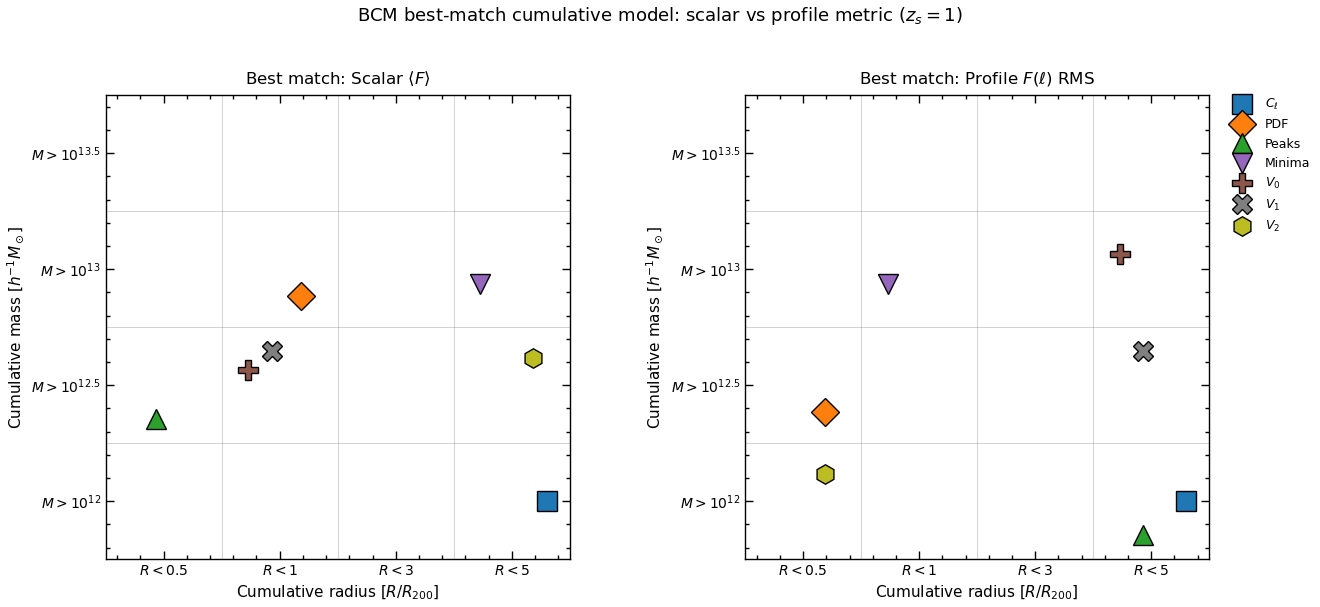

In [64]:
# ============================================================
# 8r. Side-by-side 4×4 grids: scalar <F> vs profile F(ℓ)
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for ax, best_dict, title_metric in [
    (ax1, best_cum,         r'Scalar $\langle F \rangle$'),
    (ax2, best_profile_cum, r'Profile $F(\ell)$ RMS'),
]:
    ax.set_xlim(-0.5, 3.5)
    ax.set_ylim(-0.5, 3.5)
    ax.invert_yaxis()
    for g in range(5):
        ax.axhline(g - 0.5, color='grey', lw=0.5, alpha=0.5)
        ax.axvline(g - 0.5, color='grey', lw=0.5, alpha=0.5)
    
    n = len(STATS_NO_PK)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    jitter_r = 0.3
    
    for k, stat in enumerate(STATS_NO_PK):
        i_row, j_col = best_dict[stat][0], best_dict[stat][1]
        dx = jitter_r * np.cos(angles[k])
        dy = jitter_r * np.sin(angles[k])
        ax.plot(j_col + dx, i_row + dy, stat_markers[stat],
                color=stat_colors_tab[stat], ms=14, mec='k', mew=1.0, zorder=10,
                label=STAT_LABELS[stat])
    
    ax.set_xticks(range(4))
    ax.set_xticklabels(cum_rad_labels, fontsize=10)
    ax.set_yticks(range(4))
    ax.set_yticklabels(cum_mass_labels, fontsize=10)
    ax.set_xlabel(r'Cumulative radius $[R/R_{200}]$', fontsize=11)
    ax.set_ylabel(r'Cumulative mass $[h^{-1}M_\odot]$', fontsize=11)
    ax.set_title(f'Best match: {title_metric}', fontsize=12, pad=8)
    ax.set_aspect('equal')

ax2.legend(fontsize=9, ncol=1, loc='upper left', bbox_to_anchor=(1.02, 1.02),
           framealpha=0.95)
fig.suptitle(r'BCM best-match cumulative model: scalar vs profile metric ($z_s=1$)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

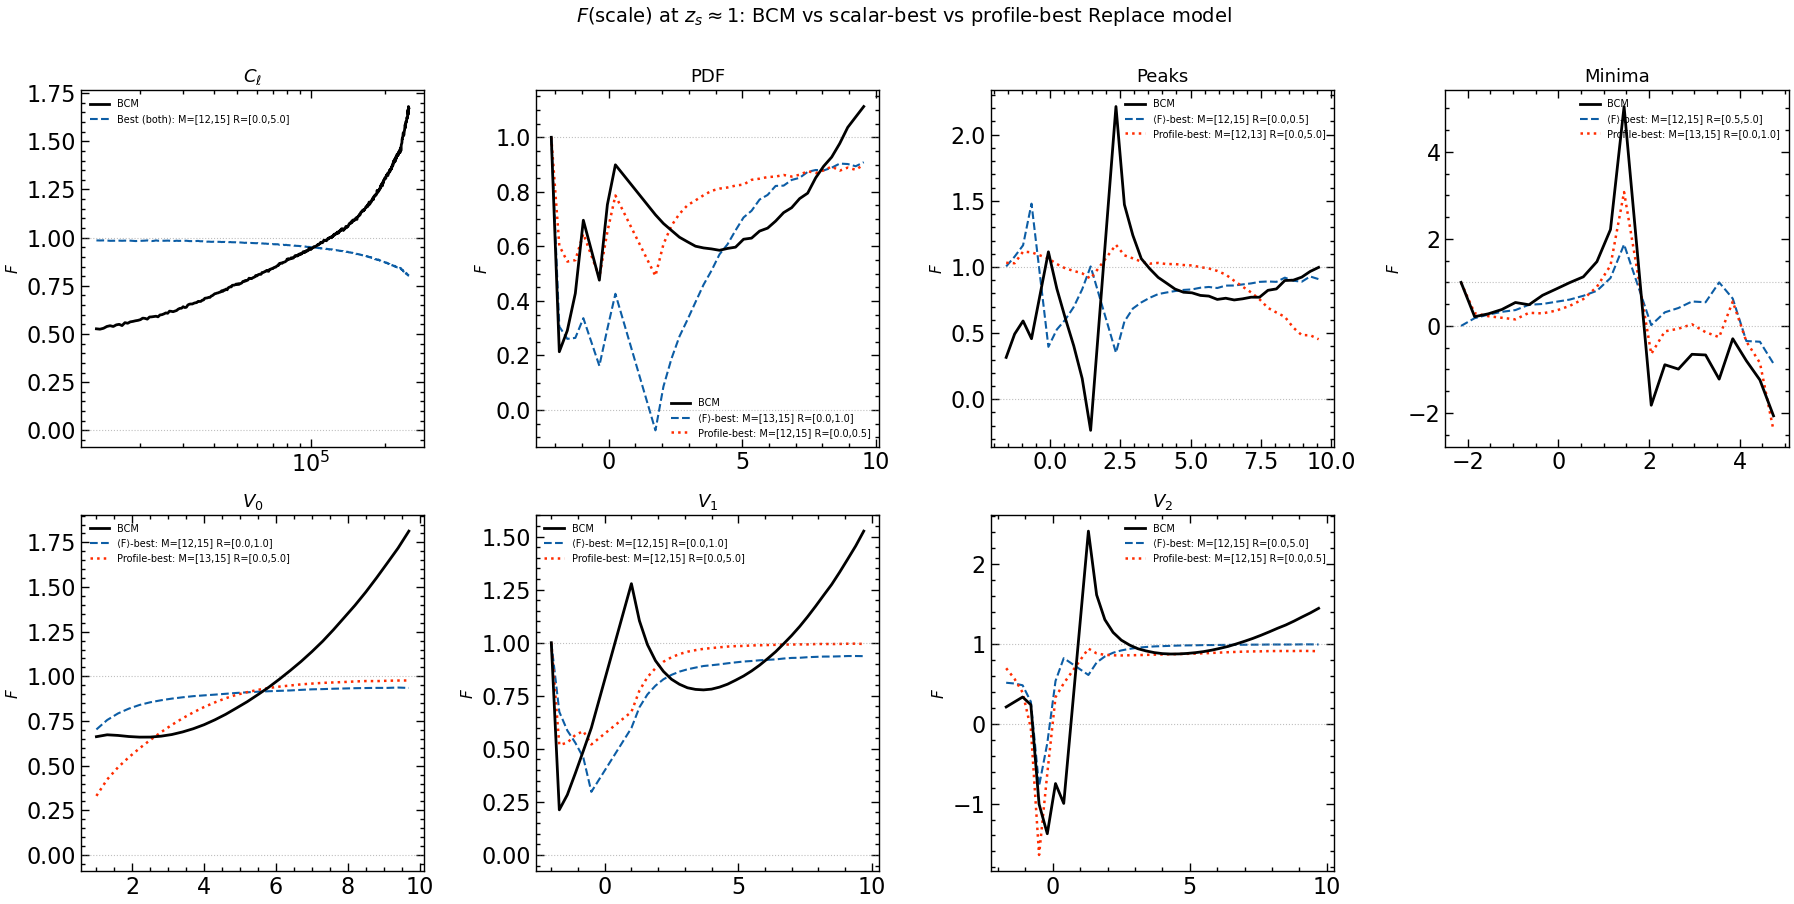

In [67]:
# ============================================================
# 8s. F(scale) profiles: BCM vs scalar-best vs profile-best
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes_flat = axes.flatten()

for si, stat in enumerate(STATS_NO_PK):
    ax = axes_flat[si]
    
    # BCM F profile at z_match
    F_bcm_prof = bcm_F[bcm_name][stat][z_match]
    bins = bcm_bins[stat]   # shape matches F bins dim
    
    # Scalar-best Replace
    scalar_best_name = best_match_z1[stat]['name']
    F_scalar_best = all_replace_F[scalar_best_name][stat][z_match]
    
    # Profile-best Replace
    prof_best_name = best_profile_z1[stat]['name']
    F_prof_best = all_replace_F[prof_best_name][stat][z_match]
    
    # Mask to finite bins (all three)
    mask = np.isfinite(F_bcm_prof) & np.isfinite(F_scalar_best) & np.isfinite(F_prof_best)
    x = bins[mask] if len(bins) == len(F_bcm_prof) else np.arange(mask.sum())
    
    ax.plot(x, F_bcm_prof[mask], 'k-', lw=2.0, label='BCM', zorder=5)
    
    same_model = (scalar_best_name == prof_best_name)
    bm_s = best_match_z1[stat]
    bm_p = best_profile_z1[stat]
    s_lab = f"M=[{bm_s['logMl']:.0f},{bm_s['logMu']:.0f}] R=[{bm_s['Ri']},{bm_s['Ro']}]"
    p_lab = f"M=[{bm_p['logMl']:.0f},{bm_p['logMu']:.0f}] R=[{bm_p['Ri']},{bm_p['Ro']}]"
    
    if same_model:
        ax.plot(x, F_scalar_best[mask], '--', color='C0', lw=1.5,
                label=f'Best (both): {s_lab}')
    else:
        ax.plot(x, F_scalar_best[mask], '--', color='C0', lw=1.5,
                label=f'⟨F⟩-best: {s_lab}')
        ax.plot(x, F_prof_best[mask], ':', color='C3', lw=1.8,
                label=f'Profile-best: {p_lab}')
    
    ax.axhline(1, color='grey', ls=':', lw=0.8, alpha=0.5)
    ax.axhline(0, color='grey', ls=':', lw=0.8, alpha=0.5)
    ax.set_title(STAT_LABELS[stat], fontsize=13)
    
    if stat in ['Pk', 'Cl']:
        ax.set_xscale('log')
    
    ax.set_ylabel('$F$', fontsize=11)
    ax.legend(fontsize=7, loc='best')

# Hide last empty panel
axes_flat[-1].axis('off')

fig.suptitle(r'$F(\mathrm{scale})$ at $z_s \approx 1$: BCM vs scalar-best vs profile-best Replace model',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()